In [1]:
import sys
import time
import pathlib
cur_path = pathlib.Path().resolve().parent.absolute()
src_loc = cur_path.joinpath("src")
util_loc = src_loc.joinpath("utils")
sys.path.append(str(cur_path))
sys.path.append(str(src_loc))
sys.path.append(str(util_loc))

# 1 Load Data

### 1.1 Setup env and load packages

In [2]:
# load the libraries and initial settings
import os
import pathlib
import time
import datetime
import subprocess
import pyarrow as pa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import json
from pathlib import Path
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from src.conf import Conf
from src.utils.utils import elapsed_time, save_data, load_data
from src.utils.sql import sql
# Load configuration
confparam_path = cur_path.joinpath("src", "conf", "conf_dev.yml")
dataparam_path = cur_path.joinpath("src", "data", "ctp_dbt_model", "dbt_project.yml")
conf = Conf(confparam_path, dataparam_path )
project_start_time = time.time()

### 1.2 query data from EDH

#### 1.2.1 Query node features

In [3]:
# query for doctor&lawyer relationship

doc_lawyer_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_doctor_lawyer_pair_dbt
"""

# query for docotr&psych relationship

doc_psych_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_doctor_psych_pair_dbt
"""

# query for doctor&repairer relationship

doc_repair_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_doctor_repairer_pair_dbt
"""

# query for vehicle relationship

vehicle_query="""
SELECT *
FROM dl_aai_sqd_claim.ctp_vehicle_connection_dbt
"""

In [4]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_lawyer_df = sql( conf=conf, fn="get", sql=doc_lawyer_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.305
Total elapsed time: 0:0:01.506


In [5]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_psych_df = sql(conf=conf, fn="get", sql=doc_psych_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.777
Total elapsed time: 0:0:02.314


In [6]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_repair_df = sql(conf=conf, fn="get", sql=doc_repair_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.894
Total elapsed time: 0:0:03.225


In [7]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
vehicle_df = sql(conf=conf, fn="get", sql=vehicle_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:00.651
Total elapsed time: 0:0:03.903


#### 1.2.2 Query node features

In [8]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
node_query='SELECT * FROM dl_aai_sqd_claim.ctp_node_exposure_features'
node_df = sql(conf=conf, fn="get", sql=node_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.658
Total elapsed time: 0:0:05.576


In [9]:
node_df

,claim_number,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,...,self_employed_flag,pre_accident_weekly_earning,late_treatment_days,amt_fitness_certificate,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult,investigation_flag,fraud_flag
0,NWRTP2002431,1,2020-11-03,Closed,Glen Pincham,0459657067,2004 Halls Creek Rd HALLS CREEK NSW 2346,1,0,1.000,...,0,1325.200,21.000,3.000,1.000,0.000,0.000,0,0,0
1,NWRTP2500698,1,2025-03-20,Open,Ayoub Stati,0458138782,107 Darlinghurst Rd POTTS POINT NSW 2011,1,0,1.000,...,0,0.000,139.000,4.000,1.000,0.000,0.000,0,0,0
2,NWRTP2301996,1,2023-08-22,Closed,RUFUS WOODS,0426202090,116 EDMONDSON AVE AUSTRAL NSW 2179,0,0,1.000,...,0,150.000,36.000,1.000,0.000,0.000,0.000,0,0,0
3,NWRND2400023,1,2024-02-13,Closed,Voula Souris,0435343263,42 Jedda Rd LURNEA NSW 2170,1,1,0.000,...,0,0.000,340.000,4.000,0.000,0.000,0.000,0,0,0
4,NWRTP2201162,1,2022-06-14,Closed,Paul Thomson,0437249944,10 Oxley Pl POINT CLARE NSW 2250,0,0,0.000,...,0,0.000,NaN,NaN,NaN,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35639,NWRTP2102788,1,2021-12-24,Closed,Sujin Park,0447460453,5 Roslyn Gardens GREEN POINT NSW 2251,1,1,0.000,...,0,2041.290,14.000,2.000,0.000,0.000,0.000,0,0,0
35640,NWRTP2201383,1,2022-07-12,Open,Riley Rankmore,0416511157,91 Swallow Dr ERSKINE PARK NSW 2759,1,0,1.000,...,0,0.000,1191.000,4.000,1.000,0.000,0.000,0,0,0
35641,NWRTP2303109,1,2023-12-19,Open,Mehdi Kianpour,0449836589,8 / 64-68 Cardigan St GUILDFORD NSW 2161,1,1,0.000,...,1,177.870,349.000,17.000,0.000,0.000,0.000,0,0,0
35642,NWRTP1903318,1,2019-12-02,Closed,ROBERT GARDNER,0402158916,161 STRINGYBARK RD NOWRA HILL NSW 2540,1,1,NaN,...,0,0.000,43.000,2.000,0.000,0.000,0.000,0,0,0


In [10]:
# Check for duplicates based on claim number
print('*'*60)
print("check duplicates")
duplicates = node_df[node_df.duplicated(subset=['claim_number'])]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(node_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 35644
Number of duplicates is 9665


### 1.3 create pa schema and save parquet

In [11]:
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_lawyer_df)
# save data 
save_data(doc_lawyer_df, conf.data_path, 'doc_lawyer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_psych_df)
# save data 
save_data(doc_psych_df, conf.data_path, 'doc_psych_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_repair_df)
# save data 
save_data(doc_repair_df, conf.data_path, 'doc_repair_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(vehicle_df)
# save data 
save_data(vehicle_df, conf.data_path, 'vehicle_connection_data', data_extension='parquet', schema=new_schema)


Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet


In [12]:
# save claim node data
new_schema = pa.Schema.from_pandas(node_df)
save_data(node_df, conf.data_path, 'node_feature', data_extension='parquet', schema=new_schema)

Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet


# 2 Data preprocessing

### 2.1 load data locally

In [13]:
import decimal
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder
import torch
from torch_geometric.data import Data
import numpy as np 
import pandas as pd
from torch_geometric.utils import to_networkx, degree
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_undirected
from networkx.algorithms.community import greedy_modularity_communities, louvain_communities
from datetime import date

In [14]:
project_start_time = time.time()

print('*' * 60)
print("load data locally ...")

function_start_time = time.time()
doc_lawyer_df=load_data(conf.data_path, 'doc_lawyer_connection_data',  data_extension='parquet')
doc_psych_df=load_data(conf.data_path, 'doc_psych_connection_data',  data_extension='parquet')
doc_repair_df=load_data(conf.data_path, 'doc_repair_connection_data',  data_extension='parquet')
vehicle_df=load_data(conf.data_path, 'vehicle_connection_data',  data_extension='parquet')
node_df=load_data(conf.data_path, 'node_feature',  data_extension='parquet')

elapsed_time('load data', project_start_time, function_start_time)

************************************************************
load data locally ...
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet

Elapsed time (load data): 0:0:00.175
Total elapsed time: 0:0:00.176


In [15]:
conf.data_path

'C:\\GitHub\\CTP_syndicate_model\\data'

### 2.2 Node features engineering 

In [16]:
# input_dataframe=merged_df.copy()
input_dataframe=node_df.copy()
input_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35644 entries, 0 to 35643
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   claim_number                        35644 non-null  object 
 1   claim_exposure_id                   35644 non-null  int64  
 2   claim_exposure_lodgement_date       35644 non-null  object 
 3   claim_exposure_status_name          35644 non-null  object 
 4   contact_full_name                   35644 non-null  object 
 5   fixed_contact_number                34865 non-null  object 
 6   full_address                        35626 non-null  object 
 7   not_fit_for_work_flag               35644 non-null  int64  
 8   off_work_minor_injury_flag          35644 non-null  int64  
 9   not_threshold_injury_flag           34090 non-null  float64
 10  days_of_minor_assess_to_lodgement   34090 non-null  float64
 11  suspacious_not_working_flag         35644

In [17]:
def data_transformation(input_dataframe):
        """
        Function to perform data preparation steps on the given model_data DataFrame.

        Args:
        - input_dataframe: DataFrame containing the data to be prepared

        Returns:
        - model_data: DataFrame with the prepared data including node features
        """

        # Remove duplicates from input dataframe
        input_dataframe = input_dataframe.drop_duplicates(subset=['claim_number'], keep='first')

        # fill the missing value

        fill_zero_cols = [
                'not_fit_for_work_flag',
                'off_work_minor_injury_flag',
                'not_threshold_injury_flag',
                'days_of_minor_assess_to_lodgement',
                'suspacious_not_working_flag',
                'self_employed_flag',
                'pre_accident_weekly_earning',
                'late_treatment_days',
                'amt_fitness_certificate',
                'cof_holiday_weekend_flag',
                'cof_issue_to_received_over_2m_flag',
                'rejected_pay_over_8_flag',
                'gp05_pay_exceed_gp_consult'
        ]

        for x in fill_zero_cols:
                input_dataframe[x].fillna(0, inplace=True)

        # Column Selection
        # Numeric columns
        num_cols = [
                'days_of_minor_assess_to_lodgement',
                'pre_accident_weekly_earning',
                'amt_fitness_certificate',
                'late_treatment_days',
        ]
        #One hot encodin
        ohe_cols = [
                'not_fit_for_work_flag',
                'off_work_minor_injury_flag',
                'not_threshold_injury_flag',
                'suspacious_not_working_flag',
                'self_employed_flag',
                'cof_holiday_weekend_flag',
                'cof_issue_to_received_over_2m_flag',
                'rejected_pay_over_8_flag',
                'gp05_pay_exceed_gp_consult'
        ]
        #id_columns
        id_cols = [    
                'claim_number',
                'claim_exposure_id',
                'claim_exposure_lodgement_date',
                'claim_exposure_status_name',
                'contact_full_name',
                'fixed_contact_number',
                'full_address',
                'investigation_flag',
                'fraud_flag'
        ]

        features=  id_cols+ num_cols + ohe_cols
        df_node_feature = input_dataframe[features].copy()
        df_node_feature[ohe_cols]=df_node_feature[ohe_cols].astype(int)
        
        # df_node_id = input_dataframe[id_cols].copy()
        df_node_feature['claim_exposure_id']=  df_node_feature['claim_number'] + '_'+  df_node_feature['claim_exposure_id'].astype(str)
        df_node_feature.drop(columns=['claim_number'], inplace=True)

        return df_node_feature

In [18]:
# perform data processing and engineering
df_node_feature = data_transformation(input_dataframe)
df_node_feature.head()

c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\pandas\core\generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,pre_accident_weekly_earning,...,late_treatment_days,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult
0,NWRTP2002431_1,2020-11-03,Closed,Glen Pincham,0459657067,2004 Halls Creek Rd HALLS CREEK NSW 2346,0,0,57.000,1325.200,...,21.000,1,0,1,0,0,1,0,0,0
1,NWRTP2500698_1,2025-03-20,Open,Ayoub Stati,0458138782,107 Darlinghurst Rd POTTS POINT NSW 2011,0,0,0.000,0.000,...,139.000,1,0,1,0,0,1,0,0,0
2,NWRTP2301996_1,2023-08-22,Closed,RUFUS WOODS,0426202090,116 EDMONDSON AVE AUSTRAL NSW 2179,0,0,0.000,150.000,...,36.000,0,0,1,0,0,0,0,0,0
3,NWRND2400023_1,2024-02-13,Closed,Voula Souris,0435343263,42 Jedda Rd LURNEA NSW 2170,0,0,0.000,0.000,...,340.000,1,1,0,0,0,0,0,0,0
4,NWRTP2201162_1,2022-06-14,Closed,Paul Thomson,0437249944,10 Oxley Pl POINT CLARE NSW 2250,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0


### 2.3 Build CTP Claim Network

In [19]:
# def connection_(doc_lawyer_df, doc_psych_df, doc_repair_df, vehicle_df):
#     """
#     Function to create connections between nodes based on the provided DataFrames.

#     Args:
#     - doc_lawyer_df: DataFrame containing doctor-lawyer connections
#     - doc_psych_df: DataFrame containing doctor-psych connections
#     - doc_repair_df: DataFrame containing doctor-repair connections
#     - vehicle_df: DataFrame containing vehicle connections

#     Returns:
#     - doc_lawyer_df: Updated doc_lawyer connection matrix
#     - doc_psych_df: Updated doc_psych connection matrix
#     - doc_repair_df: Updated doc_repair connection matrix   
#     - vehicle_df: Updated vehicle connection matrix
#     """
    
#     # Add weight column to each connection DataFrame
#     doc_lawyer_df['weight'] = 1
#     doc_psych_df['weight'] = 1
#     doc_repair_df['weight'] = 1
#     vehicle_df['weight'] = 1

#     # Create the combined “party_name” column
#         doc_lawyer_df['party_name'] = doc_lawyer_df.apply(
#         lambda row: f"(doctor: {row['doctor_contact_name']}, lawyer: {row['lawyer_contact_name']})",
#         axis=1
#         )

#         # Create the combined “contact_number” column
#         doc_lawyer_df['party_contact_number'] = doc_lawyer_df.apply(
#         lambda row: f"(doctor: {row['doctor_contact_number']}, lawyer: {row['lawyer_contact_number']})",
#         axis=1
# )
#         # Drop the now-unneeded originals
#         doc_lawyer_df = doc_lawyer_df.drop(columns=[
#         'doctor_contact_name',
#         'lawyer_contact_name',
#         'doctor_contact_number',
#         'lawyer_contact_number'
#         ])

#     return doc_lawyer_df, doc_psych_df, doc_repair_df, vehicle_df

In [20]:
with open(Path(conf.data_path+'/doctor_name_map_clustered.json'), 'r', encoding='utf-8') as f:
    doctor_map = json.load(f)
with open(Path(conf.data_path+'/lawyer_name_map_clustered.json'), 'r', encoding='utf-8') as f:
    lawyer_map = json.load(f)
doc_lawyer_df['doctor_contact_name'] = (
    doc_lawyer_df['doctor_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(doctor_map)
                                        .fillna(doc_lawyer_df['doctor_contact_name'])
)

doc_lawyer_df['lawyer_contact_name'] = (
    doc_lawyer_df['lawyer_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(lawyer_map)
                                        .fillna(doc_lawyer_df['lawyer_contact_name'])  # keep original if not in similar-only map
)
doc_lawyer_df 

,claim_number_1,claim_exposure_id_1,claim_number_2,claim_exposure_id_2,doctor_contact_number,doctor_contact_name,lawyer_contact_number,lawyer_contact_name
0,NWRTP1802797,1,NWRTP2201167,1,0287899008,Angela Lam,0296350889,Stephen Young Lawyers Pty Ltd Law Practice Tru...
1,NWRTP2101670,1,NWRTP2501829,1,0288490102,Eric Lim,0402614477,Benefit Legal Lawyers Pty Ltd
2,NWRTP2302992,1,NWRTP2501233,1,0282111100,J Medical And Cosmetic Centre,0282624736,Littles Lawyers
3,NWRTP2302992,1,NWRTP2201860,2,0282111100,J Medical And Cosmetic Centre,0282624736,Littles Lawyers
4,NWRND2100194,1,NWRTP1902541,1,0288490102,Eric Lim,0292660046,Benefit Legal Lawyers Pty Ltd
...,...,...,...,...,...,...,...,...
16395,NWRTP2303109,1,NWRTP2302630,1,0288490102,Morgan Mo,0280469700,Walker Law Group
16396,NWRTP2001991,1,NWRTP2401913,1,0288490102,Workers Doctors,1300757467,P K Simpson And Co
16397,NWRTP1902572,1,NWRTP2100015,1,0288490102,Sebastian Calvache-rubio,0402555705,Benefit Legal Lawyers Pty Ltd
16398,NWRTP2301593,1,NWRTP2302213,1,0282111100,J Medical And Cosmetic Centre,0282624740,Littles Lawyers


In [21]:
doc_freq=doc_lawyer_df['doctor_contact_name'].value_counts()
doc_lawyer_df['doc_freq']= doc_lawyer_df['doctor_contact_name'].map(doc_freq)
doc_lawyer_df['doc_weight'] = 1.0 / doc_lawyer_df['doc_freq']**2

lawyer_freq=doc_lawyer_df['lawyer_contact_name'].value_counts()
doc_lawyer_df['lawyer_freq']= doc_lawyer_df['lawyer_contact_name'].map(lawyer_freq)
doc_lawyer_df['lawyer_weight'] = 1.0 / doc_lawyer_df['lawyer_freq']**2

# doc_lawyer_df = doc_lawyer_df[(doc_lawyer_df['doc_weight']>0.01) & (doc_lawyer_df['lawyer_weight']>0.01)]

doc_lawyer_df['weight'] = doc_lawyer_df['doc_weight'] + doc_lawyer_df['lawyer_weight']

# Create the combined “party_name” column
doc_lawyer_df['party_name'] = doc_lawyer_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, lawyer: {row['lawyer_contact_name']})",
    axis=1
)

# Create the combined “contact_number” column
doc_lawyer_df['party_contact_number'] = doc_lawyer_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_number']}, lawyer: {row['lawyer_contact_number']})",
    axis=1
)

doc_lawyer_df['claim_exposure_id_1']= doc_lawyer_df['claim_number_1'] + '_'+ doc_lawyer_df['claim_exposure_id_1'].astype(str)
doc_lawyer_df['claim_exposure_id_2']= doc_lawyer_df['claim_number_2'] + '_'+ doc_lawyer_df['claim_exposure_id_2'].astype(str)

# Drop the now-unneeded originals
doc_lawyer_df = doc_lawyer_df.drop(columns=[
    'claim_number_1',
    'claim_number_2',
    'doctor_contact_name',
    'lawyer_contact_name',
    'doctor_contact_number',
    'lawyer_contact_number',
    'doc_freq',
    'lawyer_freq',
    'doc_weight',   
    'lawyer_weight'
]).reset_index(drop=True)


doc_lawyer_df

,claim_exposure_id_1,claim_exposure_id_2,weight,party_name,party_contact_number
0,NWRTP1802797_1,NWRTP2201167_1,0.000,"(doctor: Angela Lam, lawyer: Stephen Young Law...","(doctor: 0287899008, lawyer: 0296350889)"
1,NWRTP2101670_1,NWRTP2501829_1,0.000,"(doctor: Eric Lim, lawyer: Benefit Legal Lawye...","(doctor: 0288490102, lawyer: 0402614477)"
2,NWRTP2302992_1,NWRTP2501233_1,0.000,"(doctor: J Medical And Cosmetic Centre, lawyer...","(doctor: 0282111100, lawyer: 0282624736)"
3,NWRTP2302992_1,NWRTP2201860_2,0.000,"(doctor: J Medical And Cosmetic Centre, lawyer...","(doctor: 0282111100, lawyer: 0282624736)"
4,NWRND2100194_1,NWRTP1902541_1,0.000,"(doctor: Eric Lim, lawyer: Benefit Legal Lawye...","(doctor: 0288490102, lawyer: 0292660046)"
...,...,...,...,...,...
16395,NWRTP2303109_1,NWRTP2302630_1,0.000,"(doctor: Morgan Mo, lawyer: Walker Law Group)","(doctor: 0288490102, lawyer: 0280469700)"
16396,NWRTP2001991_1,NWRTP2401913_1,0.000,"(doctor: Workers Doctors, lawyer: P K Simpson ...","(doctor: 0288490102, lawyer: 1300757467)"
16397,NWRTP1902572_1,NWRTP2100015_1,0.000,"(doctor: Sebastian Calvache-rubio, lawyer: Ben...","(doctor: 0288490102, lawyer: 0402555705)"
16398,NWRTP2301593_1,NWRTP2302213_1,0.000,"(doctor: J Medical And Cosmetic Centre, lawyer...","(doctor: 0282111100, lawyer: 0282624740)"


In [22]:
doc_psych_df['doctor_contact_name'] = (
    doc_psych_df['doctor_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(doctor_map)
                                        .fillna(doc_psych_df['doctor_contact_name'])
)

doc_freq=doc_psych_df['doctor_contact_name'].value_counts()
doc_psych_df['doc_freq']= doc_psych_df['doctor_contact_name'].map(doc_freq)
doc_psych_df['doc_weight'] = 1.0 / doc_psych_df['doc_freq']**2

psych_freq=doc_psych_df['psych_contact_name'].value_counts()
doc_psych_df['psych_freq']= doc_psych_df['psych_contact_name'].map(psych_freq)
doc_psych_df['psych_weight'] = 1.0 / doc_psych_df['psych_freq']**2

# doc_psych_df = doc_psych_df[(doc_psych_df['doc_weight']>0.01) & (doc_psych_df['psych_weight']>0.01)]

doc_psych_df['weight'] = doc_psych_df['doc_weight'] + doc_psych_df['psych_weight']

doc_psych_df['party_name'] = doc_psych_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, psych: {row['psych_contact_name']})",
    axis=1
)
doc_psych_df['party_contact_number'] = doc_psych_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_number']}, psych: {row['psych_contact_number']})",
    axis=1
)

doc_psych_df['claim_exposure_id_1']= doc_psych_df['claim_number_1'] + '_'+ doc_psych_df['claim_exposure_id_1'].astype(str)
doc_psych_df['claim_exposure_id_2']= doc_psych_df['claim_number_2'] + '_'+ doc_psych_df['claim_exposure_id_2'].astype(str)

doc_psych_df = doc_psych_df.drop(columns=[
    'claim_number_1',
    'claim_number_2',
    'doctor_contact_name',
    'psych_contact_name',
    'doctor_contact_number',
    'psych_contact_number',
    'doc_freq',
    'psych_freq',       
    'doc_weight',
    'psych_weight'
]).reset_index(drop=True)

doc_psych_df

,claim_exposure_id_1,claim_exposure_id_2,weight,party_name,party_contact_number
0,NWRTP2400728_1,NWRTP2403533_1,0.035,"(doctor: Rubina Siddiqui, psych: Peter Kim)","(doctor: 0288490102, psych: 0478242998)"
1,NWRTP1800831_1,NWRTP2300210_1,0.115,"(doctor: Sebestian Rubio, psych: Erin Carmody)","(doctor: None, psych: None)"
2,NWRTP2403533_1,NWRTP2300210_1,0.006,"(doctor: Morgan Mo, psych: Insightful Mind)","(doctor: 0288490102, psych: 0425263288)"
3,NWRTP2301351_1,NWRTP2201899_1,1.028,"(doctor: Alan Dao, psych: Shannon Mair)","(doctor: None, psych: None)"
4,NWRTP2403533_1,NWRTP2201899_1,0.064,"(doctor: Ben Dickson, psych: Insightful Mind)","(doctor: 0288490102, psych: 0425263288)"
...,...,...,...,...,...
143,NWRTP2002025_1,NWRTP2201899_1,0.065,"(doctor: S Calvache-R, psych: Workers Doctors)","(doctor: 0288490102, psych: 0288490102)"
144,NWRTP1902080_1,NWRTP1902478_1,0.038,"(doctor: Aaron Tso, psych: Hansen Li)","(doctor: None, psych: None)"
145,NWRTP1902080_1,NWRTP2201899_1,0.014,"(doctor: Sebastian Calvache-rubio, psych: Jess...","(doctor: 0288490102, psych: None)"
146,NWRTP2002025_1,NWRTP2000366_1,0.003,"(doctor: Eric Lim, psych: Workers Doctors)","(doctor: 0288490102, psych: 0288490102)"


In [23]:
doc_repair_df['doctor_contact_name'] = (
    doc_repair_df['doctor_contact_name'].map(lambda x: x.strip() if isinstance(x, str) else x)
                                        .map(doctor_map)
                                        .fillna(doc_repair_df['doctor_contact_name'])
)

doc_freq=doc_repair_df['doctor_contact_name'].value_counts()
doc_repair_df['doc_freq']= doc_repair_df['doctor_contact_name'].map(doc_freq)
doc_repair_df['doc_weight'] = 1.0 / doc_repair_df['doc_freq']**2

repair_freq=doc_repair_df['repairer_name'].value_counts()
doc_repair_df['repair_freq']= doc_repair_df['repairer_name'].map(repair_freq)
doc_repair_df['repair_weight'] = 1.0 / doc_repair_df['repair_freq']**2

# doc_repair_df = doc_repair_df[(doc_repair_df['doc_weight']>0.01) & (doc_repair_df['repair_weight']>0.01)]

doc_repair_df['weight'] = doc_repair_df['doc_weight'] + doc_repair_df['repair_weight']


doc_repair_df['party_name'] = doc_repair_df.apply(
    lambda row: f"(doctor: {row['doctor_contact_name']}, repairer_name: {row['repairer_name']})",
    axis=1
)

doc_repair_df.rename(
    columns={
        'doctor_contact_number': 'party_contact_number'
    },
    inplace=True
)

doc_repair_df['claim_exposure_id_1']= doc_repair_df['claim_number_1'] + '_'+ doc_repair_df['claim_exposure_id_1'].astype(str)
doc_repair_df['claim_exposure_id_2']= doc_repair_df['claim_number_2'] + '_'+ doc_repair_df['claim_exposure_id_2'].astype(str)

doc_repair_df = doc_repair_df.drop(columns=[
    'claim_number_1',
    'claim_number_2', 
    'doctor_contact_name',      
    'repairer_name',
    'doc_freq',
    'repair_freq',  
    'doc_weight',
    'repair_weight'
])


doc_repair_df

,claim_exposure_id_1,claim_exposure_id_2,party_contact_number,weight,party_name
0,NWRTP2401878_1,NWRTP2400645_1,0260584444,0.278,"(doctor: Lehaslenie Thirukuman, repairer_name:..."
1,NWRTP2302396_1,NWRTP1903181_1,0291055000,0.278,"(doctor: Northern Beaches Hospital, repairer_n..."
2,NWRTP2501118_1,NWRTP2201871_1,0243202111,0.252,"(doctor: Rebecca Cui, repairer_name: ADAMS SMA..."
3,NWRTP2202061_1,NWRTP1902731_2,0255242000,1.250,"(doctor: So Jung Shim, repairer_name: TAREE TI..."
4,NWRTP1901439_1,NWRTP2000392_1,0243041333,1.002,"(doctor: Amin Shaabani, repairer_name: ADAMS S..."
...,...,...,...,...,...
59,NWRTP2300568_1,NWRTP2202367_1,0299267111,0.252,(doctor: Royal North Shore And Ryde Health Ser...
60,NWRTP2400207_1,NWRTP2302010_1,None,1.111,"(doctor: Joshua Chow, repairer_name: NATURELAN..."
61,NWRTP2402283_1,NWRTP2300568_1,0299267111,0.252,"(doctor: Allen Lu, repairer_name: ADAMS SMASH ..."
62,NWRTP2501123_1,NWRTP2201317_1,0259431000,1.250,"(doctor: Morgan Prince, repairer_name: GRAEME ..."


In [24]:
vehicle_df.rename(
    columns={
        'rego_number': 'party_name'
    },
    inplace=True
)
vehicle_df['claim_exposure_id_1']= vehicle_df['claim_number_1'] + '_'+ vehicle_df['claim_exposure_id_1'].astype(str)
vehicle_df['claim_exposure_id_2']= vehicle_df['claim_number_2'] + '_'+ vehicle_df['claim_exposure_id_2'].astype(str)

party_freq = vehicle_df['party_name'].value_counts()
vehicle_df['freq_party'] = vehicle_df['party_name'].map(party_freq)
vehicle_df['weight'] = 1.0 / vehicle_df['freq_party']**2

# vehicle_df = vehicle_df[(vehicle_df['weight']>0.01)]

# Drop the now-unneeded originals
vehicle_df = vehicle_df.drop(columns=[
    'claim_number_1',
    'claim_number_2',
    'freq_party'
])

vehicle_df


,claim_exposure_id_1,claim_exposure_id_2,party_name,weight
0,NWRTP2500391_2,NWRTP2500259_1,AXD15L,0.250
1,NWRTP2101919_1,NWRTP2101556_1,DSM023,0.250
2,NWRTP2001453_1,NWRTP2000680_1,DXO08B,0.250
3,NWRTP2102718_1,NWRTP2102230_1,MMX61,0.250
4,NWRND1900143_1,NWRND1900048_1,1NV1EL,0.250
...,...,...,...,...
121,NWRTP1902155_2,NWRTP1902154_2,500SUS,0.250
122,NWRTP2400980_1,NWRTP2500758_1,KYW739,0.250
123,DPNTP2400010_1,NWRTP2403493_1,FPM47,0.250
124,DPNTP2400008_1,DPNTP2400009_1,VET50,0.028


In [25]:
# indicate connection/relationship type for further use
doc_lawyer_df['connection_type'] = 'doc_lawyer'
doc_psych_df['connection_type'] = 'doc_psych'
doc_repair_df['connection_type'] = 'doc_repair'
vehicle_df['connection_type'] = 'vehicle'

In [26]:
# concatnate all different type of edges
edges_all= pd.concat(
    [doc_lawyer_df, doc_psych_df, doc_repair_df, vehicle_df],
    ignore_index=True,
    sort=False  
)

In [27]:
#For undirected graphs, sort the node IDs in each edge to treat (u, v) and (v, u) as the same
edges_all['edge']=edges_all.apply(lambda row: tuple([row['claim_exposure_id_1'], row['claim_exposure_id_2']]), axis=1)
# Efficiently create unordered pair columns without apply
# edges_all['id_min'] = np.minimum(edges_all['claim_exposure_id_1'], edges_all['claim_exposure_id_2'])
# edges_all['id_max'] = np.maximum(edges_all['claim_exposure_id_1'], edges_all['claim_exposure_id_2'])

In [28]:
edges_grouped = edges_all.groupby(['edge']).agg({
    'weight': 'sum',
    'connection_type': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
    'party_name': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
    'party_contact_number': lambda x: list(i for i in x if pd.notna(i)) if len(x) > 0 else None,
}).reset_index()

#Split 'edge' back into 'source' and 'target'
edges_grouped[['claim_exposure_id_1', 'claim_exposure_id_2']] = pd.DataFrame(edges_grouped['edge'].tolist(), index=edges_grouped.index)
edges_grouped = edges_grouped.drop(columns='edge')
edges_grouped

,weight,connection_type,party_name,party_contact_number,claim_exposure_id_1,claim_exposure_id_2
0,0.250,[vehicle],[CZD04E],[],DPNTP2400001_1,NWRTP2402003_2
1,0.250,[vehicle],[EEC01V],[],DPNTP2400002_1,NWRTP2402179_2
2,0.250,[vehicle],[EUS59E],[],DPNTP2400003_1,NWRTP2400461_1
3,0.250,[vehicle],[BNE97B],[],DPNTP2400004_1,NWRTP2402845_1
4,0.250,[vehicle],[CY13BV],[],DPNTP2400005_1,NWRTP2102179_1
...,...,...,...,...,...,...
15771,0.001,[doc_lawyer],"[(doctor: Predrag Tomasevic, lawyer: Carters L...","[(doctor: 0298241588, lawyer: 0269490233)]",NWRTP2502155_1,NWRTP2100409_1
15772,0.001,[doc_lawyer],"[(doctor: Predrag Tomasevic, lawyer: Carters L...","[(doctor: 0298241588, lawyer: 0269490233)]",NWRTP2502155_1,NWRTP2102359_1
15773,0.001,[doc_lawyer],"[(doctor: Predrag Tomasevic, lawyer: Carters L...","[(doctor: 0298241588, lawyer: 0269490233)]",NWRTP2502155_1,NWRTP2102359_2
15774,0.001,[doc_lawyer],"[(doctor: Predrag Tomasevic, lawyer: Carters L...","[(doctor: 0298241588, lawyer: 0269490233)]",NWRTP2502155_1,NWRTP2302269_1


In [29]:
print(len(df_node_feature))
df_node_feature.head(5)

25979


,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,pre_accident_weekly_earning,...,late_treatment_days,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult
0,NWRTP2002431_1,2020-11-03,Closed,Glen Pincham,0459657067,2004 Halls Creek Rd HALLS CREEK NSW 2346,0,0,57.000,1325.200,...,21.000,1,0,1,0,0,1,0,0,0
1,NWRTP2500698_1,2025-03-20,Open,Ayoub Stati,0458138782,107 Darlinghurst Rd POTTS POINT NSW 2011,0,0,0.000,0.000,...,139.000,1,0,1,0,0,1,0,0,0
2,NWRTP2301996_1,2023-08-22,Closed,RUFUS WOODS,0426202090,116 EDMONDSON AVE AUSTRAL NSW 2179,0,0,0.000,150.000,...,36.000,0,0,1,0,0,0,0,0,0
3,NWRND2400023_1,2024-02-13,Closed,Voula Souris,0435343263,42 Jedda Rd LURNEA NSW 2170,0,0,0.000,0.000,...,340.000,1,1,0,0,0,0,0,0,0
4,NWRTP2201162_1,2022-06-14,Closed,Paul Thomson,0437249944,10 Oxley Pl POINT CLARE NSW 2250,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0


In [30]:
# Create a mapping from node IDs to indices, including all nodes from df_node_features
# Extract node IDs from node features
feature_node_ids = set(df_node_feature['claim_exposure_id'])

# Extract node IDs from edges
edge_node_ids = set(edges_grouped['claim_exposure_id_1']).union(edges_grouped['claim_exposure_id_2'])

if edge_node_ids.issubset(feature_node_ids):
    print("All edge_node_ids are in feature_node_ids.")
else:
    missing_nodes = edge_node_ids - feature_node_ids
    print("Nodes in edge_node_ids but not in feature_node_ids:")
    print(missing_nodes)
    # now filter edges_grouped in-place (or assign to a new DF)
    edges_grouped = edges_grouped[
    edges_grouped['claim_exposure_id_1'].isin(feature_node_ids) &
    edges_grouped['claim_exposure_id_2'].isin(feature_node_ids)
        ].reset_index(drop=True)



Nodes in edge_node_ids but not in feature_node_ids:
{'NWRTP1901106_1', 'NWRTP2501695_1', 'NWRTP2201919_1', 'NWRTP2001974_2', 'NWRTP2402573_3', 'NWRTP2402505_2', 'NWRTP2100105_6', 'NWRTP1802268_2', 'NWRTP1903354_2', 'NWRTP2002916_3', 'NWRTP2202793_3', 'NWRTP2300305_2', 'NWRND1900047_3', 'NWRTP1803061_1', 'NWRTP1901952_2', 'NWRTP2400398_6', 'NWRTP2001513_1', 'NWRTP2400134_1', 'NWRTP2300209_2', 'NWRTP2201056_4', 'NWRTP2002272_1', 'NWRTP2300362_1', 'NWRTP1800967_2', 'NWRTP2302647_3', 'NWRND1800164_1', 'NWRTP1801577_1', 'NWRTP2402081_3', 'NWRTP1903372_2', 'NWRTP2001995_4', 'NWRTP2002639_3', 'NWRTP1902778_2', 'NWRND1900074_2', 'NWRND2000025_6', 'NWRTP2102359_2', 'NWRTP2201868_1', 'NWRTP2201167_2', 'NWRTP1901354_2', 'NWRTP2301946_4', 'NWRTP2201497_1', 'NWRTP1901952_3', 'NWRTP1800128_1', 'NWRTP2200580_2', 'NWRTP2401209_2', 'NWRTP2500129_1', 'NWRTP2102072_2', 'NWRTP2301900_2', 'NWRTP2501074_4', 'NWRTP2101496_3', 'NWRTP2000702_1', 'NWRTP2201871_1', 'NWRTP2300356_8', 'NWRTP2400129_5', 'NWRTP24017

In [31]:
# # Filter out rows where 'source' or 'target' is in the exclusion set
# edges_grouped = edges_grouped[
#     ~edges_grouped['claim_exposure_id_1'].isin(missing_nodes) &
#     ~edges_grouped['claim_exposure_id_2'].isin(missing_nodes)
# ]

In [32]:
# Extract node IDs from edges
edge_node_ids = set(edges_grouped['claim_exposure_id_1']).union(edges_grouped['claim_exposure_id_2'])

# Extract node IDs from node features
feature_node_ids = set(df_node_feature['claim_exposure_id'])

if edge_node_ids.issubset(feature_node_ids):
    print("All edge_node_ids are in feature_node_ids.")

# # Union of all node IDs
all_node_ids = edge_node_ids.union(feature_node_ids)

# Create mapping from node IDs to indices
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(sorted(all_node_ids))}

All edge_node_ids are in feature_node_ids.


In [33]:
# Map claim number to indices in edges
edges_grouped['source_idx'] = edges_grouped['claim_exposure_id_1'].map(node_id_to_idx)
edges_grouped['target_idx'] = edges_grouped['claim_exposure_id_2'].map(node_id_to_idx)
# Prepare node features, including nodes without edges
df_node_feature['node_idx'] = df_node_feature['claim_exposure_id'].map(node_id_to_idx)


all_nodes_df = df_node_feature.sort_values('node_idx').reset_index(drop=True).set_index('node_idx')
all_nodes_df

,claim_exposure_id,claim_exposure_lodgement_date,claim_exposure_status_name,contact_full_name,fixed_contact_number,full_address,investigation_flag,fraud_flag,days_of_minor_assess_to_lodgement,pre_accident_weekly_earning,...,late_treatment_days,not_fit_for_work_flag,off_work_minor_injury_flag,not_threshold_injury_flag,suspacious_not_working_flag,self_employed_flag,cof_holiday_weekend_flag,cof_issue_to_received_over_2m_flag,rejected_pay_over_8_flag,gp05_pay_exceed_gp_consult
node_idx,,,,,,,,,,,,,,,,,,,,,
0,DPNTP2400001_1,2024-08-12,Closed,THOMAS URBAN,0407460058,3 MARANOA ST WYOMING NSW 2250,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
1,DPNTP2400002_1,2024-09-19,Closed,TIM HILLIER,0423682146,5 TRISTANIA CRES TAREE NSW 2430,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
2,DPNTP2400003_1,2024-10-04,Closed,SARAH BLEWITT,0458076999,15 WOOLALLA ST COOMA NSW 2630,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
3,DPNTP2400004_1,2024-10-18,Closed,The Estate of the Late ELIAS DOUAIHY,0432067868,311 BUNGARRIBEE RD BLACKTOWN NSW 2148,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
4,DPNTP2400005_1,2024-10-22,Closed,Samantha Smith,None,987 Murrays Run Road LAGUNA NSW 2325,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25974,NWRTP2502181_1,2025-08-11,Open,Sophia Farhat,0406135013,194 Marion Street BANKSTOWN NSW 2200,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
25975,NWRTP2502182_1,2025-08-11,Open,Charles Caraig,0466627679,12 Blumer Av GRIFFITH NSW 2680,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0
25976,NWRTP2502183_1,2025-08-11,Open,Mohini Lata,0404600869,403 / 12 Rancom St BOTANY NSW 2019,0,0,0.000,0.000,...,0.000,0,0,0,0,0,0,0,0,0


In [34]:

id_cols = [    
        'claim_exposure_id',
        'claim_exposure_lodgement_date',
        'claim_exposure_status_name',
        'contact_full_name',
        'fixed_contact_number',
        'full_address',
        'node_idx',
        'investigation_flag',
        'fraud_flag'
]
feature_cols=df_node_feature.columns.drop(id_cols)
feature_cols

Index(['days_of_minor_assess_to_lodgement', 'pre_accident_weekly_earning',
       'amt_fitness_certificate', 'late_treatment_days',
       'not_fit_for_work_flag', 'off_work_minor_injury_flag',
       'not_threshold_injury_flag', 'suspacious_not_working_flag',
       'self_employed_flag', 'cof_holiday_weekend_flag',
       'cof_issue_to_received_over_2m_flag', 'rejected_pay_over_8_flag',
       'gp05_pay_exceed_gp_consult'],
      dtype='object')

In [35]:
# Extract node features as a tensor
x = torch.tensor(all_nodes_df[feature_cols].values, dtype=torch.float)
# Create edge_index tensor
edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)
# edge_index = to_undirected(edge_index)

# Create edge_weight tensor
edge_weight = torch.tensor(edges_grouped['weight'].values, dtype=torch.float)
# Create investigation label tensor
y = torch.tensor(all_nodes_df['investigation_flag'].values, dtype=torch.long)

C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3453500741.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)


In [36]:
# Create PyG data object as CTP claim network
data = Data(x=x, edge_index=edge_index, edge_weight=edge_weight,y=y)
data

Data(x=[25979, 13], edge_index=[2, 9842], y=[25979], edge_weight=[9842])

In [37]:
from torch_geometric.utils import is_undirected
#validate undirected graph
is_undirected(data.edge_index)

True

In [38]:
# Filepath to save the data object
graph_path = os.path.join(conf.data_path, 'ctp_pyg_data.pt')

torch.save(data, graph_path)

# save node data 
new_schema = pa.Schema.from_pandas(all_nodes_df)
save_data(all_nodes_df, conf.data_path, 'node_features', data_extension='parquet', schema=new_schema)

# save edge data 
new_schema = pa.Schema.from_pandas(edges_grouped)
save_data(edges_grouped, conf.data_path, 'edge_features', data_extension='parquet', schema=new_schema)



Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_features.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\edge_features.parquet


### 2.4 Visualize the Network

In [39]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [40]:
# Load the data object
graph_path = os.path.join(conf.data_path, 'ctp_pyg_data.pt')
# data=torch.load(graph_path)

# all_nodes_df=load_data(conf.data_path, 'node_features',  data_extension='parquet')
# edges_grouped=load_data(conf.data_path, 'edge_features',  data_extension='parquet')

In [41]:
# # Convert PyG object to networkx data object
# G = to_networkx(data, node_attrs=['x', 'y'], edge_attrs=['edge_weight'], to_undirected=True)
G = to_networkx(data, to_undirected=True, edge_attrs=['edge_weight'],node_attrs=['x'])
# Add claim_number as node attribute in networkx graph G
num_nodes_org = G.number_of_nodes()
num_edges_org = G.number_of_edges()
print(f"Number of nodes: {num_nodes_org}")
print(f"Number of edges: {num_edges_org}")

Number of nodes: 25979
Number of edges: 4921


In [42]:
nx.set_node_attributes(G, all_nodes_df['claim_exposure_id'].to_dict(), 'claim_exposure_id')
nx.set_node_attributes(G, all_nodes_df['claim_exposure_lodgement_date'].to_dict(), 'claim_exposure_lodgement_date')
nx.set_node_attributes(G, all_nodes_df['claim_exposure_status_name'].to_dict(), 'claim_exposure_status_name')
nx.set_node_attributes(G, all_nodes_df['contact_full_name'].to_dict(), 'contact_full_name')
nx.set_node_attributes(G, all_nodes_df['fixed_contact_number'].to_dict(), 'fixed_contact_number')
nx.set_node_attributes(G, all_nodes_df['full_address'].to_dict(), 'full_address')
nx.set_node_attributes(G, all_nodes_df['investigation_flag'].to_dict(), 'investigation_flag')
nx.set_node_attributes(G, all_nodes_df['fraud_flag'].to_dict(), 'fraud_flag')

In [43]:
G.remove_nodes_from(list(nx.isolates(G)))

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 1339
Number of edges: 4921


In [44]:
node_percentage=num_nodes/num_nodes_org
edge_percentage=num_edges/num_edges_org

print('The percentage of remaining nodes is {:.2%}, and the percentage of remaining edges is {:.2%}'.format(
    node_percentage, edge_percentage))

The percentage of remaining nodes is 5.15%, and the percentage of remaining edges is 100.00%


In [45]:
for _, row in edges_grouped.iterrows():
    source_idx = row['source_idx']
    target_idx = row['target_idx']

    if G.has_edge(source_idx, target_idx):
            G.edges[source_idx, target_idx]['connection_type'] = row['connection_type']
            G.edges[source_idx, target_idx]['party_name'] = row['party_name']
            G.edges[source_idx, target_idx]['party_contact_number'] = row['party_contact_number']

In [46]:
def visualize_G(G):
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Node colours (unchanged) ---
    node_colors = [
        'red' if data.get('y') == 1 else 'skyblue'
        for _, data in G.nodes(data=True)
    ]

    # --- Build edge labels (unchanged) ---
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        parts = []
        if 'edge_weight' in data:
            parts.append(f"W: {data['edge_weight']}")
        if 'connection_type' in data:
            ct = data['connection_type']
            if isinstance(ct, (list, tuple, set)):
                parts.append("Type: " + ", ".join(map(str, ct)))
            else:
                parts.append("Type: " + str(ct))
        edge_labels[(u, v)] = "\n".join(parts)

    # --- Determine unique connection types (flatten sets/lists) ---
    conn_types = set()
    for _, _, data in G.edges(data=True):
        ct = data.get('connection_type')

        if isinstance(ct, (list, tuple, set)):
            for t in ct:
                conn_types.add(t)
        elif ct is not None:
            conn_types.add(ct)

    # --- Assign each type a colour from tab10 ---
    cmap = plt.get_cmap('tab10')
    type_to_color = {
        ct: cmap(i % cmap.N)
        for i, ct in enumerate(sorted(conn_types))
    }
    default_edge_color = 'grey'

    # --- Build edge-colour list (pick first type if multiple) ---
    edge_colors = []
    for _, _, data in G.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)) and len(ct) > 0:
            # pick the first element in the iterable
            key = next(iter(ct))
            edge_colors.append(type_to_color.get(key, default_edge_color))
        elif ct is not None:
            edge_colors.append(type_to_color.get(ct, default_edge_color))
        else:
            edge_colors.append(default_edge_color)

    # --- Plot ---
    pos = nx.random_layout(G)
    plt.figure(figsize=(10, 7))
    nx.draw(
        G, pos,
        with_labels=False,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=400,
    )
    # nx.draw_networkx_edge_labels(
    #     G, pos,
    #     edge_labels=edge_labels,
    #     font_size=6,
    #     label_pos=0.5
    # )
    nx.draw_networkx_labels(
        G, pos,
        labels={n: d.get('claim_exposure_id', str(n)) for n, d in G.nodes(data=True)},
        font_size=6
    )

    # --- Legend for connection types ---
    for ct, col in type_to_color.items():
        plt.plot([], [], color=col, label=str(ct))
    plt.legend(title="Connection Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title('Graph with Edge Colours by Connection Type')
    plt.tight_layout()
    plt.show()


In [47]:
import random
# Define the number of nodes to sample
num_nodes_to_sample = 50  # Adjust based on your requirements

# Randomly sample nodes
sampled_nodes = random.sample(list(G.nodes()), min(num_nodes_to_sample, num_nodes))

# Create a subgraph with the sampled nodes
G_sub = G.subgraph(sampled_nodes)

In [48]:
num_nodes = G_sub.number_of_nodes()
num_edges = G_sub.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 50
Number of edges: 9


C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\2220194995.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


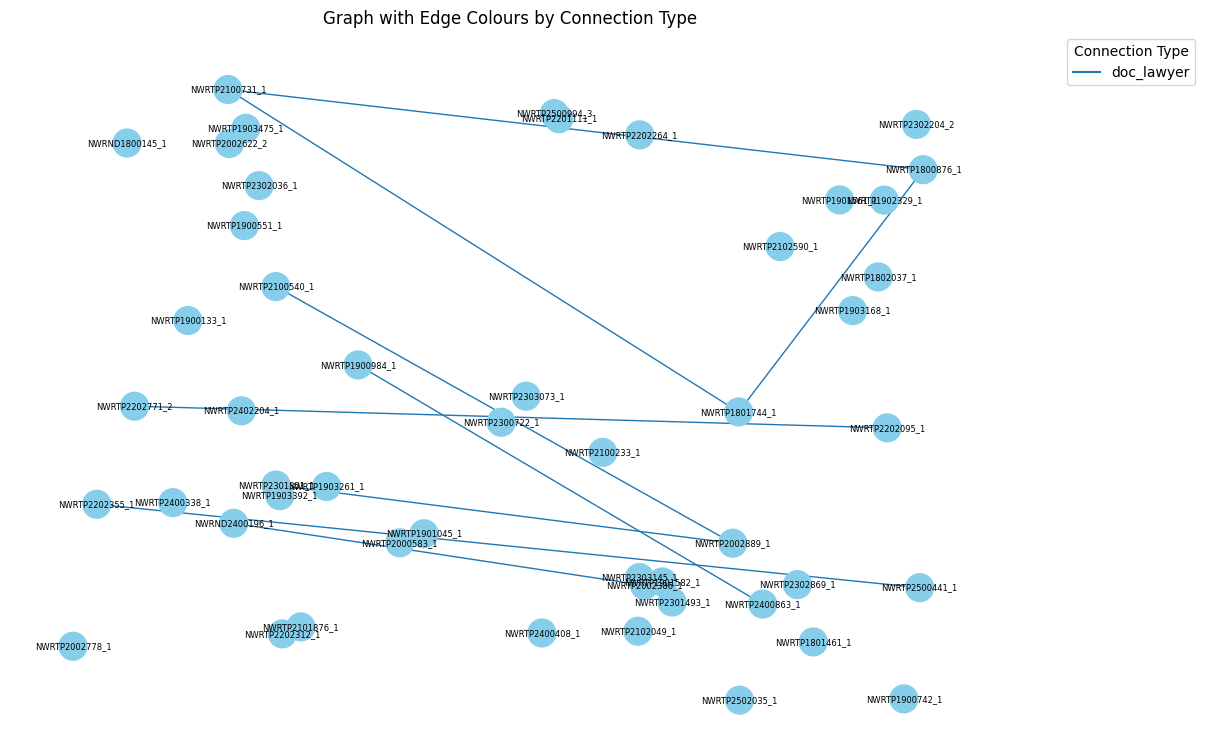

In [49]:
visualize_G(G_sub)

In [50]:
save_data(G, conf.data_path, 'ctp_network', data_extension='pkl')

Data saved successfully locally as pickle: C:\GitHub\CTP_syndicate_model\data\ctp_network.pkl


In [51]:
save_data(all_nodes_df, conf.data_path, 'node_data', data_extension='csv')

Data saved successfully locally as CSV: C:\GitHub\CTP_syndicate_model\data\node_data.csv


### 2.5 Graph Visualization

In [52]:
def visualize_community(G, communities, community_idx):
    import matplotlib.pyplot as plt
    import networkx as nx

    # --- Build the subgraph for this community ---
    selected = communities[community_idx]
    C = G.subgraph(selected)

    # --- Node colours based on 'y' ---
    node_colors = [
        'red' if data.get('y') == 1 else 'skyblue'
        for _, data in C.nodes(data=True)
    ]

    # --- Edge labels (
    # 
    #  + connection_type) ---
    edge_labels = {}
    for u, v, data in C.edges(data=True):
        parts = []
        if 'edge_weight' in data:
            parts.append(f"W: {data['edge_weight']}")
        ct = data.get('connection_type')
        if ct:
            if isinstance(ct, (list, tuple, set)):
                parts.append("Type: " + ", ".join(map(str, ct)))
            else:
                parts.append("Type: " + str(ct))
        edge_labels[(u, v)] = "\n".join(parts)

    # --- Gather unique connection types ---
    conn_types = set()
    for _, _, data in C.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)):
            conn_types.update(ct)
        elif ct is not None:
            conn_types.add(ct)

    # --- Map each type to a colour from tab10 ---
    cmap = plt.get_cmap('tab10')
    type_to_color = {
        ct: cmap(i % cmap.N)
        for i, ct in enumerate(sorted(conn_types))
    }
    default_edge_color = 'grey'

    # --- Build per-edge colour list ---
    edge_colors = []
    for _, _, data in C.edges(data=True):
        ct = data.get('connection_type')
        if isinstance(ct, (list, tuple, set)) and ct:
            key = next(iter(ct))
            edge_colors.append(type_to_color.get(key, default_edge_color))
        elif ct is not None:
            edge_colors.append(type_to_color.get(ct, default_edge_color))
        else:
            edge_colors.append(default_edge_color)

    # --- Draw ---
    pos = nx.kamada_kawai_layout(C)
    plt.figure(figsize=(6, 4))
    nx.draw(
        C, pos,
        node_color=node_colors,
        edge_color=edge_colors,
        with_labels=False,
        node_size=400
    )
    nx.draw_networkx_labels(
        C, pos,
        labels={n: d.get('claim_exposure_id', str(n)) for n, d in C.nodes(data=True)},
        font_size=6
    )

    # --- Legend for types ---
    for ct, col in type_to_color.items():
        plt.plot([], [], color=col, label=str(ct))
    plt.legend(title="Connection Type", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(f"Subgraph for Community {community_idx}")
    plt.tight_layout()
    plt.show()


### 2.6 Community Detection

In [53]:
def recursive_community_detection(G, communities_list,resolution,threshold,seed_value=42):

    random.seed(seed_value)
    np.random.seed(seed_value)
    # If the graph has 50 or fewer nodes, append it to the final communities list
    if G.number_of_nodes() <= threshold:
        communities_list.append(set(G.nodes))
    else:
        # Perform community detection on the subgraph
        # communities = nx.community.greedy_modularity_communities(G, weight='edge_weight', resolution=resolution)
        communities = louvain_communities(G, weight='edge_weight', resolution=resolution, seed=seed_value)
        
        # Apply the function recursively on the detected communities
        for community in communities:
            subgraph = G.subgraph(community)
            recursive_community_detection(subgraph, communities_list,resolution=resolution,threshold=threshold)

In [54]:
final_communities=[]
recursive_community_detection(G, final_communities, resolution=1, threshold=50)

len(final_communities)

411

In [55]:
# final_communities = louvain_communities(G, weight='edge_weight', resolution=1.2, seed=42)
# len(final_communities)

In [56]:
community_sizes = [len(c) for c in final_communities]
max(community_sizes)

47

### 2.7 Community Analysis

In [57]:
# Function to compute conductance
def compute_conductance(graph, community):
    vol_community = sum(dict(graph.degree(community)).values())
    edge_boundary = len(list(nx.edge_boundary(graph, community)))
    vol_rest = sum(dict(graph.degree(graph.nodes - community)).values())

    if vol_community>0 and vol_rest>0:  
        return edge_boundary / min(vol_community, vol_rest)  
    else:
        return 0

In [58]:
def cal_metrics_community(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)

        edge_weights = [data.get('edge_weight', 0) for u, v, data in subgraph.edges(data=True)]
        total_weight = sum(edge_weights)
        avg_edge_weight = total_weight / len(edge_weights) if edge_weights else 0

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_exposure_id']for node, data in subgraph.nodes(data=True)]

        # Clustering coefficient (average for nodes in the community)
        avg_clustering = nx.average_clustering(subgraph)
        
        # Conductance
        conductance = compute_conductance(G, community)
        
        # Density
        density = nx.density(subgraph)
        
        # Triangle count (sum of triangles in the community)
        triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        
        # Add metrics to the list
        community_metrics.append({
            'Community': i,
            'Nodes': node_list,
            'Exposure list': claim_list,
            'Average edge weight':avg_edge_weight,
            'Clustering Coefficient': avg_clustering,
            'Conductance': conductance,
            'Density': density,
            'Triangle Count': triangles,
            'Size': len(community),
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [59]:
df_metrics = cal_metrics_community(G, final_communities)
df_metrics

,Community,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size
0,0,"[0, 22251]","[DPNTP2400001_1, NWRTP2402003_2]",0.250,0.000,0.000,1.000,0,2
1,1,"[19504, 5]","[NWRTP2302438_1, DPNTP2400006_1]",0.250,0.000,0.000,1.000,0,2
2,2,"[23241, 6]","[NWRTP2403000_1, DPNTP2400007_1]",0.250,0.000,0.000,1.000,0,2
3,3,"[8, 19834, 7]","[DPNTP2400009_1, NWRTP2302768_1, DPNTP2400008_1]",0.028,1.000,0.000,1.000,1,3
4,4,"[24280, 11]","[NWRTP2500485_2, DPNTP2500001_1]",0.250,0.000,0.000,1.000,0,2
...,...,...,...,...,...,...,...,...,...
406,406,"[17474, 25277]","[NWRTP2300396_1, NWRTP2501483_1]",0.250,0.000,0.000,1.000,0,2
407,407,"[14441, 25542]","[NWRTP2200143_1, NWRTP2501748_1]",1.062,0.000,0.000,1.000,0,2
408,408,"[25715, 14254, 15926]","[NWRTP2501922_1, NWRTP2102777_1, NWRTP2201633_1]",0.059,0.000,0.000,0.667,0,3
409,409,"[13858, 25827, 12870, 9129, 12588, 3857, 10706...","[NWRTP2102380_1, NWRTP2502034_1, NWRTP2101388_...",0.006,0.940,0.000,0.917,66,9


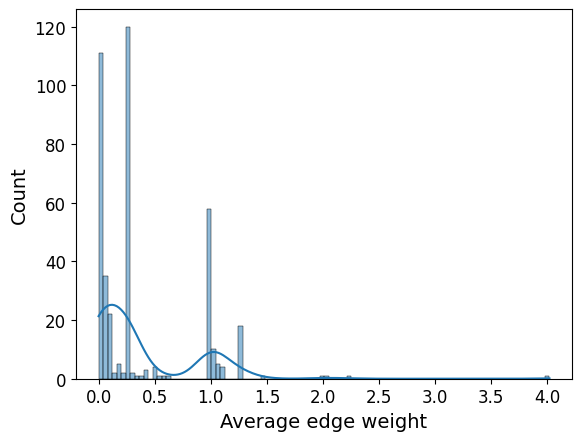

In [60]:
sns.histplot(df_metrics['Average edge weight'], kde=True, bins=100) 
plt.show()

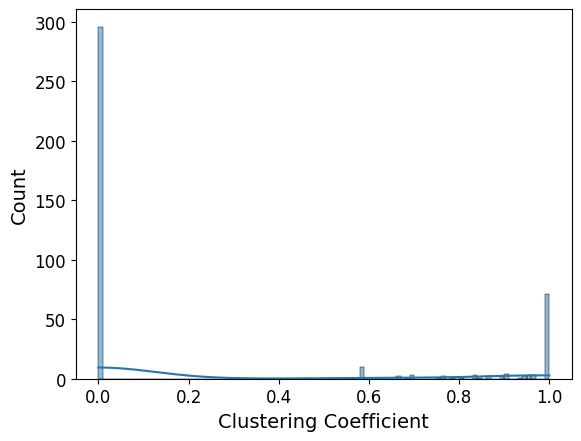

In [61]:
sns.histplot(df_metrics['Clustering Coefficient'], kde=True, bins=100) 
plt.show()

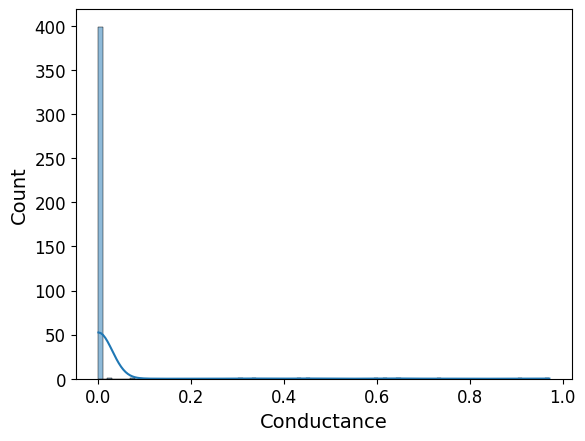

In [62]:
sns.histplot(df_metrics['Conductance'], kde=True, bins=100) 
plt.show()

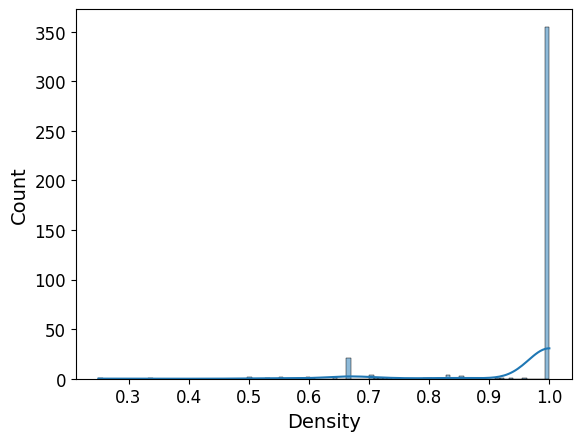

In [63]:
sns.histplot(df_metrics['Density'], kde=True, bins=100) 
plt.show()

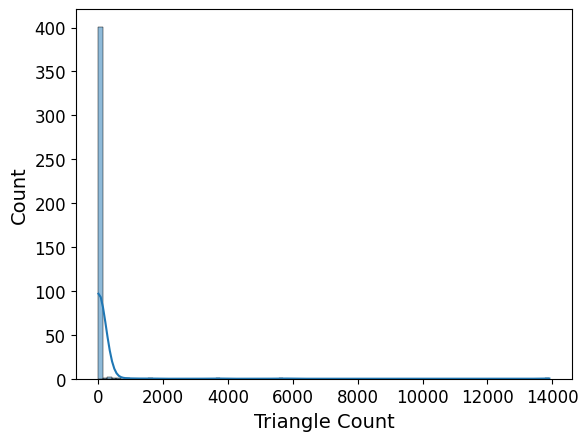

In [64]:
sns.histplot(df_metrics['Triangle Count'], kde=True, bins=100) 
plt.show()

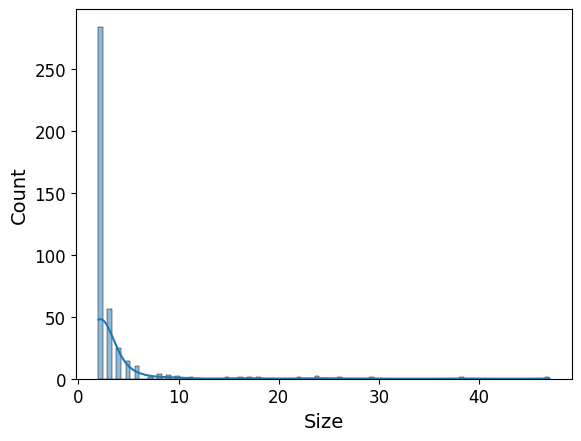

In [65]:
sns.histplot(df_metrics['Size'], kde=True, bins=100) 
plt.show()

In [66]:
# Filter communities based on criteria 
filtered_metrics = df_metrics[
    (df_metrics['Clustering Coefficient'] > 0.8) &  
    (df_metrics['Conductance'] < 0.8) &             
    (df_metrics['Density'] > 0.8) &                 
    # (df_metrics['Triangle Count'] > 2) &
    # (df_metrics['Average edge weight'] > 0.01) &
    (df_metrics['Size'] >=4 )         
].reset_index(drop=True)  

In [67]:
filtered_metrics

,Community,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size
0,10,"[148, 16223, 8958, 11191]","[NWRND1800135_1, NWRTP2201932_1, NWRTP2000400_...",0.005,1.000,0.000,1.000,4,4
1,11,"[183, 10410, 595, 999]","[NWRND1800172_1, NWRTP2001862_1, NWRND2000107_...",0.005,1.000,0.000,1.000,4,4
2,16,"[4736, 6562, 5955, 9864, 12169, 267, 4047, 571...","[NWRTP1802826_1, NWRTP1901525_1, NWRTP1900910_...",0.000,1.000,0.000,1.000,120,10
3,18,"[291, 3527, 3018, 7444, 4669]","[NWRND1900051_1, NWRTP1801607_1, NWRTP1801092_...",0.001,1.000,0.000,1.000,10,5
4,26,"[586, 9810, 18676, 9815, 8856]","[NWRND2000098_1, NWRTP2001259_1, NWRTP2301606_...",0.003,1.000,0.000,1.000,10,5
5,27,"[10152, 1385, 621, 12831]","[NWRTP2001604_1, NWRND2300160_1, NWRND2000133_...",0.008,1.000,0.000,1.000,4,4
6,29,"[8384, 6914, 17475, 817, 1202, 10646, 24890]","[NWRTP1903368_1, NWRTP1901881_1, NWRTP2300397_...",0.000,1.000,0.000,1.000,35,7
7,38,"[16210, 20234, 20667, 1167]","[NWRTP2201919_2, NWRTP2303169_1, NWRTP2400408_...",0.000,1.000,0.000,1.000,4,4
8,39,"[1185, 17809, 17059, 16385]","[NWRND2200242_1, NWRTP2300733_1, NWRTP2202771_...",0.063,1.000,0.000,1.000,4,4
9,56,"[15106, 2147, 22470, 1102, 11793, 3800]","[NWRTP2200811_1, NWRTP1800215_1, NWRTP2402223_...",0.002,0.900,0.000,0.867,13,6


In [68]:
ranked_metrics = filtered_metrics.sort_values(by=['Average edge weight','Conductance','Clustering Coefficient','Density','Size'], ascending=[False, True,False,False,False]).reset_index(drop=True)
filtered_communities = ranked_metrics['Nodes'].tolist()
len(filtered_communities)

37

In [69]:
df_filtered_metrics = cal_metrics_community(G, filtered_communities)
df_filtered_metrics.head(5)

,Community,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size
0,0,"[16944, 21338, 8740, 9478]","[NWRTP2202655_1, NWRTP2401085_1, NWRTP2000179_...",0.102,0.833,0.000,0.833,2,4
1,1,"[21848, 9937, 2826, 22793]","[NWRTP2401598_1, NWRTP2001387_1, NWRTP1800898_...",0.097,1.000,0.000,1.000,4,4
2,2,"[22593, 19139, 14156, 16414]","[NWRTP2402348_1, NWRTP2302070_1, NWRTP2102678_...",0.082,0.833,0.000,0.833,2,4
3,3,"[1185, 17809, 17059, 16385]","[NWRND2200242_1, NWRTP2300733_1, NWRTP2202771_...",0.063,1.000,0.000,1.000,4,4
4,4,"[3859, 5067, 12260, 10955]","[NWRTP1801940_1, NWRTP1900010_1, NWRTP2100776_...",0.062,1.000,0.000,1.000,4,4


In [70]:
df_filtered_metrics['rank by weight'] = df_filtered_metrics['Average edge weight'].rank(method='dense', ascending=False).astype(int)
df_filtered_metrics = df_filtered_metrics.rename(columns={'Community': 'Community_id'}).reset_index(drop=True)
df_filtered_metrics.head(10)

,Community_id,Nodes,Exposure list,Average edge weight,Clustering Coefficient,Conductance,Density,Triangle Count,Size,rank by weight
0,0,"[16944, 21338, 8740, 9478]","[NWRTP2202655_1, NWRTP2401085_1, NWRTP2000179_...",0.102,0.833,0.000,0.833,2,4,1
1,1,"[21848, 9937, 2826, 22793]","[NWRTP2401598_1, NWRTP2001387_1, NWRTP1800898_...",0.097,1.000,0.000,1.000,4,4,2
2,2,"[22593, 19139, 14156, 16414]","[NWRTP2402348_1, NWRTP2302070_1, NWRTP2102678_...",0.082,0.833,0.000,0.833,2,4,3
3,3,"[1185, 17809, 17059, 16385]","[NWRND2200242_1, NWRTP2300733_1, NWRTP2202771_...",0.063,1.000,0.000,1.000,4,4,4
4,4,"[3859, 5067, 12260, 10955]","[NWRTP1801940_1, NWRTP1900010_1, NWRTP2100776_...",0.062,1.000,0.000,1.000,4,4,5
5,5,"[3041, 5189, 16108, 7388, 15804]","[NWRTP1801116_2, NWRTP1900133_1, NWRTP2201815_...",0.059,1.000,0.000,1.000,10,5,6
6,6,"[4691, 5789, 4547, 2767]","[NWRTP1802779_1, NWRTP1900742_1, NWRTP1802631_...",0.046,1.000,0.000,1.000,4,4,7
7,7,"[2919, 7342, 23312, 6394, 2459]","[NWRTP1800992_1, NWRTP1902315_1, NWRTP2403072_...",0.027,1.000,0.000,1.000,10,5,8
8,8,"[15397, 6374, 6218, 2874, 11291]","[NWRTP2201103_1, NWRTP1901333_1, NWRTP1901175_...",0.020,1.000,0.000,1.000,10,5,9
9,9,"[13696, 14052, 1220, 1221, 6597, 19656, 5896, ...","[NWRTP2102216_1, NWRTP2102574_1, NWRND2200277_...",0.013,0.898,0.073,0.850,407,16,10


In [71]:
def generate_output(G, communities):
    """
    Given a NetworkX graph G and a list of communities (each a list of node IDs),
    returns a DataFrame with one row per undirected edge–relationship pair:
      Community_id | Claim 1 | Claim 2 | Relationship Type | Relationship Party

    Assumes:
      - G.nodes[u]['claim_number'] exists for every node u
      - G.edges[u, v]['connection_type'] is a set of types
      - G.edges[u, v] may contain:
          cust_contact_name (str or set of str),
          doctor_contact_name (str or set of str),
          lawyer_contact_name,
          psych_contact_name,
          repair_contact_name,
          rego_number (str or set of str)
    """

    rows = []
    for community_id, community in enumerate(communities):
        sub = G.subgraph(community)
        seen = set()
        
        for u, v, edge_data in sub.edges(data=True):
            conn_types = edge_data.get('connection_type', list())
            for i, rel in enumerate(conn_types):
                key = tuple(sorted((u, v))) + (rel,)
                if key in seen:
                    continue
                seen.add(key)
                party= edge_data.get('party_name', list())[i]
                # prepare party based on relationship type
                               
                rows.append({
                    'Community_id':       community_id,
                    'Claim exposure 1':            G.nodes[u]['claim_exposure_id'],
                    'Claim exposure 2':            G.nodes[v]['claim_exposure_id'],
                    'Relationship Type':  rel,
                    'Relationship Party': party
                })
    
    return pd.DataFrame(rows)

In [72]:
output_df=generate_output(G, filtered_communities)
output_df

,Community_id,Claim exposure 1,Claim exposure 2,Relationship Type,Relationship Party
0,0,NWRTP2202655_1,NWRTP2000179_1,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B..."
1,0,NWRTP2202655_1,NWRTP2401085_1,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B..."
2,0,NWRTP2401085_1,NWRTP2000179_1,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B..."
3,0,NWRTP2401085_1,NWRTP2000927_1,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B..."
4,0,NWRTP2000179_1,NWRTP2000927_1,doc_lawyer,"(doctor: Subrata Banik, lawyer: Bareungil Lawy..."
...,...,...,...,...,...
2290,36,NWRTP2100201_1,NWRTP1903246_1,doc_lawyer,"(doctor: J Medical And Cosmetic Centre, lawyer..."
2291,36,NWRTP2100201_1,NWRTP2101016_2,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La..."
2292,36,NWRTP1903246_1,NWRTP2101016_2,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La..."
2293,36,NWRTP1903246_1,NWRTP2101065_1,doc_lawyer,"(doctor: Hajeong Lee, lawyer: Stephen Young La..."


In [73]:
# rename df_encoded for Claim 1
df1 = all_nodes_df.rename(columns={
    'claim_exposure_id':           'Claim exposure 1',
    'claim_exposure_lodgement_date':   'Exposure 1 lodgement date',
    'claim_exposure_status_name':      'Exposure 1 status',
    'contact_full_name': 'Exposure 1 contact name',
    'investigation_flag': 'Exposure 1 investigation flag',

})

# then rename df_encoded for Claim 2
df2 = all_nodes_df.rename(columns={
    'claim_exposure_id':           'Claim exposure 2',
    'claim_exposure_lodgement_date':   'Exposure 2 lodgement date',
    'claim_exposure_status_name':      'Exposure 2 status',
    'contact_full_name': 'Exposure 2 contact name',
    'investigation_flag': 'Exposure 2 investigation flag'
})

# now merge onto output_df
df_output_merged = (
    output_df
    .merge(df1[['Claim exposure 1','Exposure 1 lodgement date','Exposure 1 status','Exposure 1 contact name',  'Exposure 1 investigation flag']],
           on='Claim exposure 1', how='left')
    .merge(df2[['Claim exposure 2','Exposure 2 lodgement date','Exposure 2 status','Exposure 2 contact name', 'Exposure 2 investigation flag']],
           on='Claim exposure 2', how='left')
)

new_order = [
    'Community_id',
    'Claim exposure 1', 'Exposure 1 lodgement date', 'Exposure 1 status','Exposure 1 contact name','Exposure 1 investigation flag',
    'Claim exposure 2', 'Exposure 2 lodgement date', 'Exposure 2 status','Exposure 2 contact name','Exposure 2 investigation flag',
    'Relationship Type', 'Relationship Party'
]

df_output_merged = df_output_merged[new_order]
df_output_merged['created date'] = date.today()
# inspect
df_output_merged.head()


,Community_id,Claim exposure 1,Exposure 1 lodgement date,Exposure 1 status,Exposure 1 contact name,Exposure 1 investigation flag,Claim exposure 2,Exposure 2 lodgement date,Exposure 2 status,Exposure 2 contact name,Exposure 2 investigation flag,Relationship Type,Relationship Party,created date
0,0,NWRTP2202655_1,2022-12-12,Open,Seokjin Ahn,1,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17
1,0,NWRTP2202655_1,2022-12-12,Open,Seokjin Ahn,1,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17
2,0,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17
3,0,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0,NWRTP2000927_1,2020-05-06,Closed,Eun Park,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17
4,0,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0,NWRTP2000927_1,2020-05-06,Closed,Eun Park,0,doc_lawyer,"(doctor: Subrata Banik, lawyer: Bareungil Lawy...",2025-08-17


In [74]:
# df_final_output = df_output_merged.merge(df_filtered_metrics[['Community_id', 'rank by weight']], on='Community_id', how='left')
# df_final_output.head(10)

In [75]:
# output_df.index.name = 'community_id'

# # Perform the join by resetting the index so we can join on it like a regular column
# merged_df = output_df.reset_index().merge(
#     ranked_metrics,
#     how='inner',
#     left_on='community_index',
#     right_on='Community'
# )
# merged_df.head(10)

In [76]:
# merged_df.drop(columns=['Community','Nodes', 'Claim Numbers'], inplace=True)

C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3601805149.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


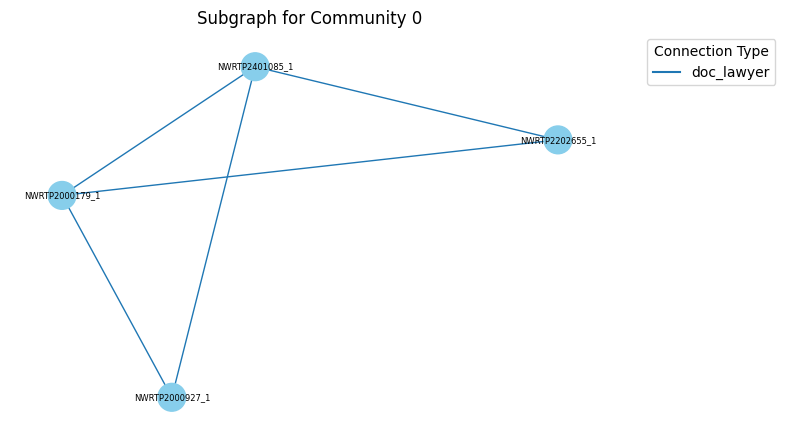

In [77]:
visualize_community(G, filtered_communities, 0)

C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3601805149.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


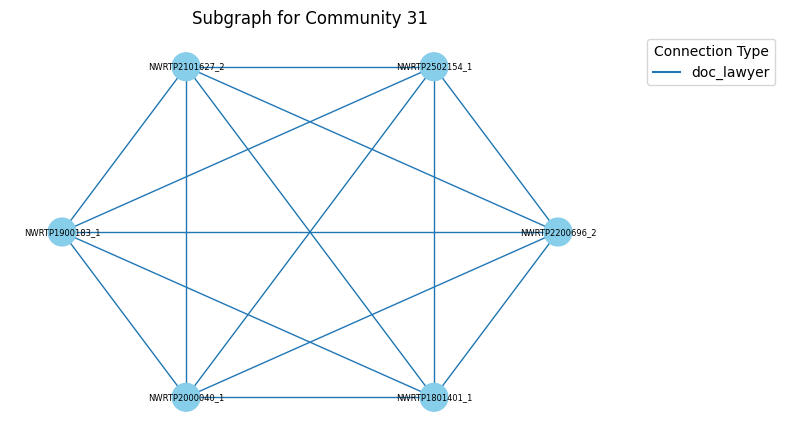

In [78]:
visualize_community(G, filtered_communities, 31)

# 3 Implement algorithms on Claim Network

In [79]:
import pytz
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, \
    f1_score, confusion_matrix, auc, precision_recall_curve,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
# from pygod.detector import DOMINANT
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from network import Dominant
import optuna

c:\GitHub\CTP_syndicate_model\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [80]:
print("num_nodes:", data.x.size(0))
print("max edge index:", int(data.edge_index.max()))

num_nodes: 25979
max edge index: 25948


In [81]:
# import torch
# import torch_geometric

# print("Torch version:", torch.__version__)
# print("Torch Geometric version:", torch_geometric.__version__)

### 3.1 Hyperparameter tuning on DOMINANT model

In [82]:
class networkEvaluator:
    """
    conf: from Conf class
    model_IF: isolation forest model
    x: input dataframe
    y: target value
    id_df: index columns of dataframe
    csv_filename: name of saving file
    thresh: threshold for model IF decision fucntion
    metric1: use as objective in HP, key in metrics dictionary
    metric2: use for comparison in plot, key in metrics dictionary
    """

    def __init__(self, conf):
        self.conf = conf

    @staticmethod
    def evaluate (conf, model, data, id_df, thresh, MODEL_TAG, csv_filename, metric1, metric2):
        anomaly_scores, y_emb=model.predict(data, get_emb=True)
        y_score = anomaly_scores.numpy()
        y_score = pd.Series(y_score, name='y_score')
        y_real= pd.Series(id_df['investigation_flag'], name='y')
        combined_df = pd.concat([y_score.reset_index(drop=True), 
                                 y_real.reset_index(drop=True)], axis=1)
        combined_df['y_pred'] = np.where(combined_df['y_score'] >= thresh, 1, 0)
        alert_vol =  sum(combined_df['y_pred'] == 1)
        
        precision = precision_score(combined_df['y'], combined_df['y_pred'])
        recall = recall_score(combined_df['y'], combined_df['y_pred'])
        f1 = f1_score(combined_df['y'], combined_df['y_pred'])
        conf_matrix = confusion_matrix(combined_df['y'], combined_df['y_pred'])
        precision2, recall2, _ = precision_recall_curve(combined_df['y'], combined_df['y_score'])
        pr_auc = auc(recall2, precision2)
        auc_roc_score = roc_auc_score(combined_df['y'], combined_df['y_score'])

        metrics = {
            "alert_vol": alert_vol,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Confusion Matrix": conf_matrix,
            "AUC-PR": pr_auc,
            "AUC-ROC": auc_roc_score
        }
        # Print metrics
        print("Evaluation Metrics:")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value}")
        
        # Save meitrics to CSV
        networkEvaluator.save_metrics_to_csv(MODEL_TAG, metrics,
                                                     metric1, metric2, csv_filename)
        return metrics, combined_df

    @staticmethod
    def save_metrics_to_csv(MODEL_TAG, metrics, metric1, metric2, csv_filename):
        try:
            metric_df = pd.read_csv(csv_filename)
        except FileNotFoundError:
            metric_df = pd.DataFrame(columns=['Model', metric1, metric2])

        new_row = pd.DataFrame({'Model': [MODEL_TAG], 
                                metric1: [metrics[metric1]], 
                                metric2: [metrics[metric2]]})
        
        metric_df = pd.concat([metric_df, new_row], ignore_index=True)
        metric_df.to_csv(csv_filename, index=False)


# evaluator for Random forest 

In [83]:

class networkTrainer:
    """
    use metric1 as objective
    use metirc2 as comparison in plot

    """
    def __init__(self, conf, data, id_train, metric1, metric2):
        self.conf = conf
        self.data = data
        self.id_train = id_train
        self.metric1 = metric1
        self.metric2 = metric2
        self.metric_results = []

    def objective(self, trial):
        # Suggest values for the hyperparameters
        hidden_size = trial.suggest_int('hidden_size', 5, self.data.x.shape[1], step=1 )
        num_epochs = trial.suggest_int('num_epochs', 50, 100, step=5 )
        learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1) 
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
        dropout = trial.suggest_uniform('dropout', 0, 0.5) 
        # Create the model with suggested hyperparameters
        params={
            'hidden_size': hidden_size,
            'num_epochs': num_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'dropout': 0
        }
        # threshold = trial.suggest_uniform('threshold', 0, 0.5)  # Optimize threshold
        MODEL_TAG = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
        model = self.train_model(self.data, params)
        metrics, combined_df = networkEvaluator.evaluate(self.conf, model, self.data, self.id_train, 
                        500, MODEL_TAG, self.conf.artefact_path + "/metrics_train.csv", 
                        self.metric1, self.metric2)
        # Save the metrics for later plotting
        self.metric_results.append({self.metric1:metrics[self.metric1], self.metric2:metrics[self.metric2]})
        return metrics[self.metric1]
    

    def train_model(self, data, params):
        model = Dominant(feat_size=data.x.shape[1], hidden_size=params['hidden_size'], dropout=params['dropout'])
        model.train_model(data, num_epochs=params['num_epochs'], learning_rate=params['learning_rate'], weight_decay=params['weight_decay'])
        return model

    def train_with_optuna(self, n_trials=50):
        study = optuna.create_study(direction='maximize')
        study.optimize(self.objective, n_trials)  # 100 trials

        best_params = study.best_params

        # Plot A2I and "New R2I" curves after all trials are finished
        self.plot_metrics_curve()

        return best_params, study

    def plot_metrics_curve(self):
        # Retrieve the desired metrics from the results
        metric1_values = [result[self.metric1] for result in self.metric_results]
        metric2_values = [result[self.metric2] for result in self.metric_results]
        trials = np.arange(1, len(metric1_values) + 1)

        # Plot the selected metrics
        plt.figure(figsize=(10, 6))
        plt.plot(trials, metric1_values, marker='o', linestyle='-', color='b', label=self.metric1)
        plt.plot(trials, metric2_values, marker='o', linestyle='-', color='r', label=self.metric2)
        plt.title('Performance Metrics for Hyperparameter Tuning Trials')
        plt.xlabel('Trial')
        plt.ylabel('Score')
        plt.legend()
        plt.tight_layout()
        plt.show()

[I 2025-08-17 20:53:52,494] A new study created in memory with name: no-name-d564bfdc-5218-46fe-81b2-d50def516459


************************************************************
HP tuning started...


C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3395842246.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3395842246.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3395842246.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0, 0.5)


Epoch 1/95, Loss: 28834117632.00, Struct loss: 28736782336.00, Attr loss: 97335.88
Epoch 2/95, Loss: 1057557632.00, Struct loss: 969464768.00, Attr loss: 88092.83
Epoch 3/95, Loss: 452705280.00, Struct loss: 364074912.00, Attr loss: 88630.36
Epoch 4/95, Loss: 174914848.00, Struct loss: 88270312.00, Attr loss: 86644.53
Epoch 5/95, Loss: 86250440.00, Struct loss: 2935784.50, Attr loss: 83314.66
Epoch 6/95, Loss: 78892224.00, Struct loss: 628.72, Attr loss: 78891.59
Epoch 7/95, Loss: 73502568.00, Struct loss: 97.90, Attr loss: 73502.47
Epoch 8/95, Loss: 67527648.00, Struct loss: 15.25, Attr loss: 67527.63
Epoch 9/95, Loss: 61105712.00, Struct loss: 0.55, Attr loss: 61105.71
Epoch 10/95, Loss: 54389092.00, Struct loss: 0.00, Attr loss: 54389.09
Epoch 11/95, Loss: 47473732.00, Struct loss: 0.00, Attr loss: 47473.73
Epoch 12/95, Loss: 41052476.00, Struct loss: 0.00, Attr loss: 41052.48
Epoch 13/95, Loss: 35018564.00, Struct loss: 0.00, Attr loss: 35018.56
Epoch 14/95, Loss: 29145542.00, Stru

[I 2025-08-17 21:01:09,128] Trial 0 finished with value: 0.010989010989010988 and parameters: {'hidden_size': 10, 'num_epochs': 95, 'learning_rate': 0.037067597638017, 'weight_decay': 0.000461069849064923, 'dropout': 0.22561857079737263}. Best is trial 0 with value: 0.010989010989010988.


...

Evaluation Metrics:
alert_vol: 19
Precision: 0.05263157894736842
Recall: 0.006024096385542169
F1 Score: 0.010810810810810811
Confusion Matrix: [[25795    18]
 [  165     1]]
AUC-PR: 0.023630616742987626
AUC-ROC: 0.7743631326141354


C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3395842246.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3395842246.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3395842246.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0, 0.5)


Epoch 1/55, Loss: 930634688.00, Struct loss: 839115904.00, Attr loss: 91518.79
Epoch 2/55, Loss: 91738136.00, Struct loss: 3783626.75, Attr loss: 87954.52
Epoch 3/55, Loss: 88426088.00, Struct loss: 1335021.88, Attr loss: 87091.06
Epoch 4/55, Loss: 85689088.00, Struct loss: 299804.47, Attr loss: 85389.28
Epoch 5/55, Loss: 81376456.00, Struct loss: 30206.42, Attr loss: 81346.25
Epoch 6/55, Loss: 75793608.00, Struct loss: 2699.43, Attr loss: 75790.91
Epoch 7/55, Loss: 68832144.00, Struct loss: 483.30, Attr loss: 68831.66
Epoch 8/55, Loss: 59101736.00, Struct loss: 19.34, Attr loss: 59101.71
Epoch 9/55, Loss: 46693340.00, Struct loss: 3.33, Attr loss: 46693.34
Epoch 10/55, Loss: 33324234.00, Struct loss: 0.00, Attr loss: 33324.23
Epoch 11/55, Loss: 25310090.00, Struct loss: 0.00, Attr loss: 25310.09
Epoch 12/55, Loss: 24463610.00, Struct loss: 0.00, Attr loss: 24463.61
Epoch 13/55, Loss: 16668219.00, Struct loss: 0.00, Attr loss: 16668.22
Epoch 14/55, Loss: 8967288.00, Struct loss: 0.00, 

[I 2025-08-17 22:25:02,937] Trial 19 finished with value: 0.010869565217391304 and parameters: {'hidden_size': 8, 'num_epochs': 55, 'learning_rate': 0.07473331416602474, 'weight_decay': 0.01558397260674835, 'dropout': 0.18713459409971095}. Best is trial 14 with value: 0.041666666666666664.


Evaluation Metrics:
alert_vol: 18
Precision: 0.05555555555555555
Recall: 0.006024096385542169
F1 Score: 0.010869565217391304
Confusion Matrix: [[25796    17]
 [  165     1]]
AUC-PR: 0.023152836942559925
AUC-ROC: 0.7681756740672837


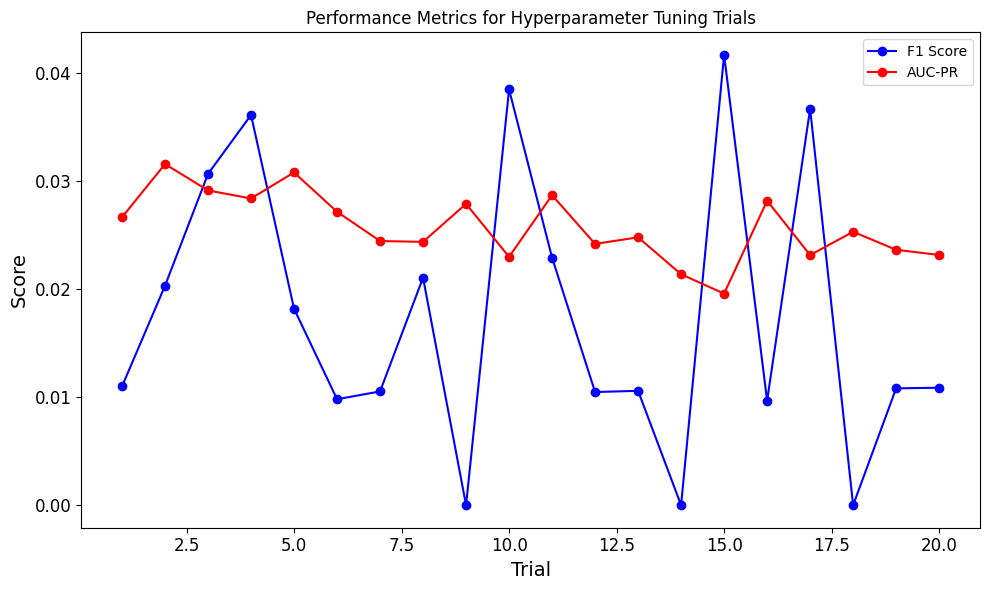

Best Parameters: {'hidden_size': 8, 'num_epochs': 65, 'learning_rate': 0.016373516127106205, 'weight_decay': 0.004410557297953017, 'dropout': 0.1832963452012002}
HP tuning finished...
************************************************************

Elapsed time (model HP tuning): 1:31:10.797
Total elapsed time: 1:31:20.772


In [84]:
# init params
hptrial = 20 # number of trials in HP tuning
metric1 = 'F1 Score' # use as objective in HP tuning
metric2 = 'AUC-PR' # use for HP tuning tracking

# train_tag = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
print('*' * 60)
print('HP tuning started...')
# use New T2D as objective
# run on 2024-02-16
function_start_time = time.time()
# Instantiate the trainer
trainer = networkTrainer(conf, data, all_nodes_df, metric1, metric2)
# Train with Optuna
best_params, study = trainer.train_with_optuna(n_trials=hptrial)
trial_data = study.trials_dataframe()
# save_pkl(best_params, conf.artefact_path, "best_params", data_extension="pkl")
# save_pkl(trial_data, conf.artefact_path, "trial_data_{}".format(train_tag), data_extension="pkl")
print("Best Parameters:", best_params)
print('HP tuning finished...')
print('*' * 60)
elapsed_time('model HP tuning', project_start_time, function_start_time)

### 3.2 Train model and extract network embeddings

In [85]:
# Initialize model
model = Dominant(feat_size=data.x.shape[1], hidden_size=best_params['hidden_size'], dropout=0)
model.train_model(data, num_epochs=best_params['num_epochs'], learning_rate=best_params['learning_rate'], weight_decay=best_params['weight_decay'])

Epoch 1/65, Loss: 2176329216.00, Struct loss: 2076513152.00, Attr loss: 99816.15
Epoch 2/65, Loss: 715593408.00, Struct loss: 619836096.00, Attr loss: 95757.31
Epoch 3/65, Loss: 271905152.00, Struct loss: 178903760.00, Attr loss: 93001.41
Epoch 4/65, Loss: 137391664.00, Struct loss: 46111380.00, Attr loss: 91280.28
Epoch 5/65, Loss: 101628048.00, Struct loss: 11416724.00, Attr loss: 90211.32
Epoch 6/65, Loss: 93305840.00, Struct loss: 3800476.00, Attr loss: 89505.37
Epoch 7/65, Loss: 90413480.00, Struct loss: 1685291.25, Attr loss: 88728.20
Epoch 8/65, Loss: 88811328.00, Struct loss: 936038.06, Attr loss: 87875.29
Epoch 9/65, Loss: 87629312.00, Struct loss: 637427.00, Attr loss: 86991.89
Epoch 10/65, Loss: 86553120.00, Struct loss: 511275.88, Attr loss: 86041.85
Epoch 11/65, Loss: 85450856.00, Struct loss: 451441.94, Attr loss: 84999.41
Epoch 12/65, Loss: 84263160.00, Struct loss: 413358.06, Attr loss: 83849.80
Epoch 13/65, Loss: 82974536.00, Struct loss: 385442.38, Attr loss: 82589.09

Dominant(
  (shared_encoder): Encoder(
    (gc1): GCNConv(13, 8)
    (gc2): GCNConv(8, 8)
  )
  (attr_decoder): Attribute_Decoder(
    (gc1): GCNConv(8, 8)
    (gc2): GCNConv(8, 13)
  )
  (struct_decoder): Structure_Decoder(
    (gc1): GCNConv(8, 8)
  )
)

### 3.3 Evaluate graph anomaly detection model

In [86]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

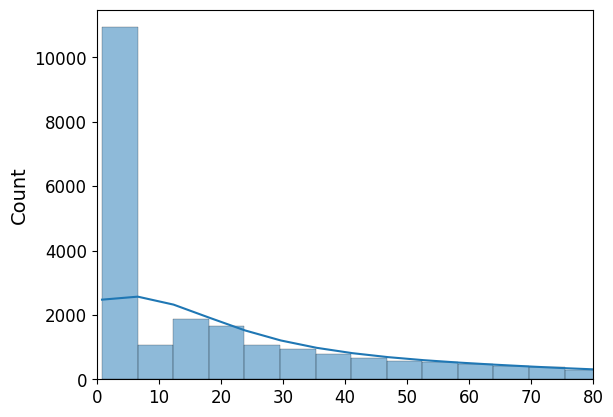

In [87]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(anomaly_scores, kde=True, bins=200) 
plt.xlim(0,80) 
plt.show()

In [88]:
train_tag=datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')

In [89]:
all_metrics_dfs = []
for thresh in range(10,50, 10):
        metrics, combined_df = networkEvaluator.evaluate(conf,model, data, all_nodes_df, 
                          thresh, train_tag, conf.artefact_path + "/metrics_train.csv", 
                          'F1 Score', 'AUC-PR')
                # Convert metrics dict to DataFrame (assuming keys are the metric names)
        metrics_df = pd.DataFrame([metrics])
        
        # Add a column for the threshold to track which metrics belong to which threshold
        metrics_df['threshold'] = thresh
        # Append the DataFrame to the list
        all_metrics_dfs.append(metrics_df)
# Concatenate all the DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

Evaluation Metrics:
alert_vol: 14410
Precision: 0.010201249132546842
Recall: 0.8855421686746988
F1 Score: 0.02017014270032931
Confusion Matrix: [[11550 14263]
 [   19   147]]
AUC-PR: 0.02938529807757194
AUC-ROC: 0.7916729872264793
Evaluation Metrics:
alert_vol: 11482
Precision: 0.01201881205364919
Recall: 0.8313253012048193
F1 Score: 0.023695054945054944
Confusion Matrix: [[14469 11344]
 [   28   138]]
AUC-PR: 0.02938529807757194
AUC-ROC: 0.7916729872264793
Evaluation Metrics:
alert_vol: 9327
Precision: 0.014045244987670204
Recall: 0.7891566265060241
F1 Score: 0.027599283682713575
Confusion Matrix: [[16617  9196]
 [   35   131]]
AUC-PR: 0.02938529807757194
AUC-ROC: 0.7916729872264793
Evaluation Metrics:
alert_vol: 7791
Precision: 0.015402387370042356
Recall: 0.7228915662650602
F1 Score: 0.030162121402538645
Confusion Matrix: [[18142  7671]
 [   46   120]]
AUC-PR: 0.02938529807757194
AUC-ROC: 0.7916729872264793


In [90]:
combined_metrics_df

,alert_vol,Precision,Recall,F1 Score,Confusion Matrix,AUC-PR,AUC-ROC,threshold
0,14410,0.010,0.886,0.020,"[[11550, 14263], [19, 147]]",0.029,0.792,10
1,11482,0.012,0.831,0.024,"[[14469, 11344], [28, 138]]",0.029,0.792,20
2,9327,0.014,0.789,0.028,"[[16617, 9196], [35, 131]]",0.029,0.792,30
3,7791,0.015,0.723,0.030,"[[18142, 7671], [46, 120]]",0.029,0.792,40


ROC-AUC: 0.79


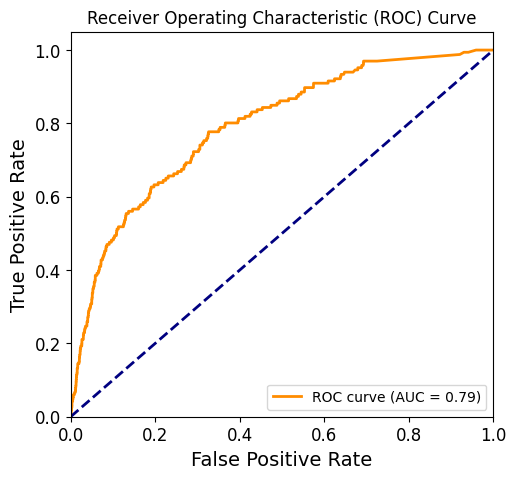

In [91]:
# ROC Curve
y_score=anomaly_scores
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")


# 4 Score Clusters

### 4.1 Anomaly Score

In [92]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

In [93]:
def generate_community_output(G, communities):   
    # Collect metrics for each community
    community_metrics = []

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)
        
        community_anomaly_scores = [anomaly_scores[node] for node in community]
        # avg_anomaly_score = sum(community_anomaly_scores) / len(community_anomaly_scores) if community_anomaly_scores else 0
    
        # Calculate metrics for anomaly scores within the community
        mean_score = np.mean(community_anomaly_scores)
        max_score = np.max(community_anomaly_scores)
        # sum_score = np.sum(community_anomaly_scores)

        edge_weights = [data.get('edge_weight', 0) for u, v, data in subgraph.edges(data=True)]
        total_weight = sum(edge_weights)
        avg_edge_weight = total_weight / len(edge_weights) if edge_weights else 0

        node_list=[node for node, data in subgraph.nodes(data=True)]
        # Retrieve claim numbers:
        claim_list=[data['claim_exposure_id']for node, data in subgraph.nodes(data=True)]

        investigation_list = [data['investigation_flag'] for node, data in subgraph.nodes(data=True) if data['investigation_flag'] != 0]
        
        fraud_list = [data['fraud_flag'] for node, data in subgraph.nodes(data=True) if data['fraud_flag'] != 0]

        # # Clustering coefficient (average for nodes in the community)
        # avg_clustering = nx.average_clustering(subgraph)
        
        # # Conductance
        # conductance = compute_conductance(G, community)
        
        # # Density
        # density = nx.density(subgraph)
        
        # # Triangle count (sum of triangles in the community)
        # triangles = sum(nx.triangles(subgraph).values()) // 3  # Each triangle is counted thrice

        # Calculate percentage of nodes with y == 1
        total_nodes = len(community)
        # y_count = sum(1 for node, data in subgraph.nodes(data=True) if data.get('y', 0) == 1)
        y_count =  len(investigation_list)
        y_percentage = (y_count / total_nodes * 100) if total_nodes > 0 else 0
        
        # Add metrics to the list
        community_metrics.append({
            'Community_id': i,
            'Nodes': node_list,
            'Claim Numbers': claim_list,
            'Average edge weight':avg_edge_weight,
            'Investigated count': len(investigation_list),
            'mean_anomaly_score': mean_score,
            'max_anomaly_score': max_score,
            'Fraud count':len(fraud_list),
            'Size': len(community),
            'investigation_rate': y_percentage # Optionally add community size
        })

    # Create a DataFrame
    df_metrics = pd.DataFrame(community_metrics)
    return df_metrics

In [94]:
community_df = generate_community_output(G, filtered_communities)
community_df.head(10)

,Community_id,Nodes,Claim Numbers,Average edge weight,Investigated count,mean_anomaly_score,max_anomaly_score,Fraud count,Size,investigation_rate
0,0,"[16944, 21338, 8740, 9478]","[NWRTP2202655_1, NWRTP2401085_1, NWRTP2000179_...",0.102,1,199.926,281.751,0,4,25.000
1,1,"[21848, 9937, 2826, 22793]","[NWRTP2401598_1, NWRTP2001387_1, NWRTP1800898_...",0.097,0,73.122,181.417,0,4,0.000
2,2,"[22593, 19139, 14156, 16414]","[NWRTP2402348_1, NWRTP2302070_1, NWRTP2102678_...",0.082,0,162.857,334.611,0,4,0.000
3,3,"[1185, 17809, 17059, 16385]","[NWRND2200242_1, NWRTP2300733_1, NWRTP2202771_...",0.063,0,196.213,345.709,0,4,0.000
4,4,"[3859, 5067, 12260, 10955]","[NWRTP1801940_1, NWRTP1900010_1, NWRTP2100776_...",0.062,0,250.087,526.778,0,4,0.000
5,5,"[3041, 5189, 16108, 7388, 15804]","[NWRTP1801116_2, NWRTP1900133_1, NWRTP2201815_...",0.059,0,159.564,290.695,0,5,0.000
6,6,"[4691, 5789, 4547, 2767]","[NWRTP1802779_1, NWRTP1900742_1, NWRTP1802631_...",0.046,0,25.592,65.027,0,4,0.000
7,7,"[2919, 7342, 23312, 6394, 2459]","[NWRTP1800992_1, NWRTP1902315_1, NWRTP2403072_...",0.027,0,118.042,184.930,0,5,0.000
8,8,"[15397, 6374, 6218, 2874, 11291]","[NWRTP2201103_1, NWRTP1901333_1, NWRTP1901175_...",0.020,0,116.512,286.679,0,5,0.000
9,9,"[13696, 14052, 1220, 1221, 6597, 19656, 5896, ...","[NWRTP2102216_1, NWRTP2102574_1, NWRND2200277_...",0.013,0,164.180,461.384,0,16,0.000


In [95]:
# community_df.sort_values(by=['investigation_rate','rank_by_mean_anomaly_score'], 
#                          ascending=[False, True], inplace=True)
# community_df=community_df.reset_index(drop=True)
# community_df

In [96]:
# Create rank columns (lower rank = higher value)
community_df['rank_by_max_anomaly_score'] = community_df['max_anomaly_score'].rank(method='first', ascending=False).astype(int)
community_df['rank_by_mean_anomaly_score'] = community_df['mean_anomaly_score'].rank(method='first', ascending=False).astype(int)
community_df['rank_by_edge_weight'] = community_df['Average edge weight'].rank(method='first', ascending=False).astype(int)

community_df.sort_values(by=['rank_by_max_anomaly_score', 'rank_by_mean_anomaly_score', 'rank_by_edge_weight'], 
                         ascending=[True, True, True], inplace=True)
community_df=community_df.reset_index(drop=True)
community_df


,Community_id,Nodes,Claim Numbers,Average edge weight,Investigated count,mean_anomaly_score,max_anomaly_score,Fraud count,Size,investigation_rate,rank_by_max_anomaly_score,rank_by_mean_anomaly_score,rank_by_edge_weight
0,32,"[11776, 21120, 16770, 17539, 899, 21251, 6151,...","[NWRTP2100291_1, NWRTP2400863_1, NWRTP2202481_...",0.000,2,184.158,818.896,0,47,4.255,1,10,33
1,24,"[24993, 15650, 16963, 5476, 24033, 17286, 1309...","[NWRTP2501199_1, NWRTP2201356_1, NWRTP2202674_...",0.001,1,210.474,766.102,0,17,5.882,2,6,25
2,29,"[8384, 6914, 17475, 817, 1202, 10646, 24890]","[NWRTP1903368_1, NWRTP1901881_1, NWRTP2300397_...",0.000,1,270.543,679.923,0,7,14.286,3,2,30
3,25,"[19335, 13837, 11893, 20407, 25948]","[NWRTP2302269_1, NWRTP2102359_1, NWRTP2100409_...",0.001,0,242.174,606.756,0,5,0.000,4,5,26
4,14,"[6885, 6722, 10700, 6437]","[NWRTP1901852_1, NWRTP1901687_1, NWRTP2002153_...",0.006,0,161.629,571.007,0,4,0.000,5,15,15
5,16,"[513, 5281, 5447, 7783, 8428, 6926, 6162, 8115...","[NWRND2000024_2, NWRTP1900228_1, NWRTP1900396_...",0.005,0,191.754,565.650,0,11,0.000,6,9,17
6,4,"[3859, 5067, 12260, 10955]","[NWRTP1801940_1, NWRTP1900010_1, NWRTP2100776_...",0.062,0,250.087,526.778,0,4,0.000,7,4,5
7,36,"[11688, 8265, 12499, 12548]","[NWRTP2100201_1, NWRTP1903246_1, NWRTP2101016_...",0.000,0,333.025,494.084,0,4,0.000,8,1,37
8,31,"[14992, 25947, 13108, 5238, 8601, 3323]","[NWRTP2200696_2, NWRTP2502154_1, NWRTP2101627_...",0.000,0,172.153,492.575,0,6,0.000,9,12,32
9,9,"[13696, 14052, 1220, 1221, 6597, 19656, 5896, ...","[NWRTP2102216_1, NWRTP2102574_1, NWRND2200277_...",0.013,0,164.180,461.384,0,16,0.000,10,13,10


In [97]:
df_final_output =df_output_merged.merge(community_df[['Community_id', 'rank_by_max_anomaly_score', 'investigation_rate']],
                                        on='Community_id', how='left')
df_final_output.head(10)

,Community_id,Claim exposure 1,Exposure 1 lodgement date,Exposure 1 status,Exposure 1 contact name,Exposure 1 investigation flag,Claim exposure 2,Exposure 2 lodgement date,Exposure 2 status,Exposure 2 contact name,Exposure 2 investigation flag,Relationship Type,Relationship Party,created date,rank_by_max_anomaly_score,investigation_rate
0,0,NWRTP2202655_1,2022-12-12,Open,Seokjin Ahn,1,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17,26,25.000
1,0,NWRTP2202655_1,2022-12-12,Open,Seokjin Ahn,1,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17,26,25.000
2,0,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17,26,25.000
3,0,NWRTP2401085_1,2024-04-30,Open,Prapakharan Mariappan,0,NWRTP2000927_1,2020-05-06,Closed,Eun Park,0,doc_lawyer,"(doctor: Strathfield Medical Centre, lawyer: B...",2025-08-17,26,25.000
4,0,NWRTP2000179_1,2020-01-24,Closed,Sol Oh,0,NWRTP2000927_1,2020-05-06,Closed,Eun Park,0,doc_lawyer,"(doctor: Subrata Banik, lawyer: Bareungil Lawy...",2025-08-17,26,25.000
5,1,NWRTP2401598_1,2024-06-20,Closed,Emin Buyukkopru,0,NWRTP1800898_1,2018-05-08,Closed,NADIR KAYA,0,doc_lawyer,"(doctor: Nasrin Mostaphazadeh, lawyer: Sayan A...",2025-08-17,30,0.000
6,1,NWRTP2401598_1,2024-06-20,Closed,Emin Buyukkopru,0,NWRTP2001387_1,2020-07-09,Closed,MEHMET SOYLEMEZO,0,doc_lawyer,"(doctor: Nasrin Mostaphazadeh, lawyer: Sayan A...",2025-08-17,30,0.000
7,1,NWRTP2401598_1,2024-06-20,Closed,Emin Buyukkopru,0,NWRTP2402548_1,2024-09-20,Open,Mehmet Kay,0,doc_lawyer,"(doctor: Yasar Oner, lawyer: Gio Ctp)",2025-08-17,30,0.000
8,1,NWRTP2001387_1,2020-07-09,Closed,MEHMET SOYLEMEZO,0,NWRTP1800898_1,2018-05-08,Closed,NADIR KAYA,0,doc_lawyer,"(doctor: Yasar Oner, lawyer: Sayan And Associa...",2025-08-17,30,0.000
9,1,NWRTP2001387_1,2020-07-09,Closed,MEHMET SOYLEMEZO,0,NWRTP2402548_1,2024-09-20,Open,Mehmet Kay,0,doc_lawyer,"(doctor: Yasar Oner, lawyer: Gio Ctp)",2025-08-17,30,0.000


In [98]:
table_schema='dl_aai_sqd_claim'
table_name ='ctp_syndicate_output'
sql(conf=conf, fn="write", sql=None, schema=table_schema, name=table_name, value=df_final_output, method='replace')
df_final_output.to_csv('ctp_community_output.csv', index=False)

In [99]:
global_avg_degree = sum(dict(G.degree()).values()) / len(G.nodes())
global_avg_degree


7.350261389096341

C:\Users\s745998\AppData\Local\Temp\ipykernel_26992\3601805149.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


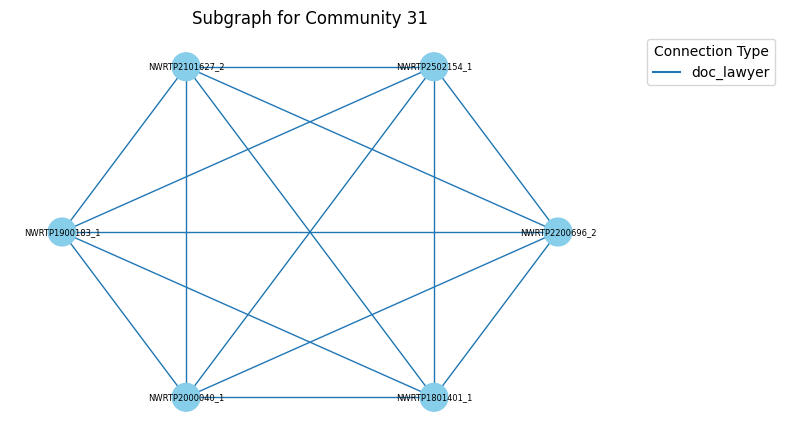

In [100]:
visualize_community(G, filtered_communities, 31)